In [1]:
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize 
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from transformers import TFBertModel, AutoTokenizer
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
from transformers import logging
from matplotlib.ticker import MaxNLocator
import math
from transformers import pipeline
from functools import partial
from scipy.optimize import curve_fit
import json
import itertools
from scipy.special import comb
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import random
import string

import networkx as nx
import matplotlib.pyplot as plt
import os
# from pyvis.network import Network
import sknetwork
from IPython.display import SVG
from sknetwork.visualization import svg_graph
from sknetwork.ranking import PageRank
import numpy as np
from sklearn.utils import Bunch
from networkx.classes.function import density
import statsmodels.api as sm

warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

In [2]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

In [3]:
## use the clauses in the original dataset.
story_processed_all = [story_all[i]['segmentation'] for i in np.arange(9)]

story_processed_marked = [string.split("\n") for string in story_processed_all]  # split into single clauses.
story_processed_all = [[item[3:] if item[2] == "." 
                        else item[2:] if item[1] == "."
                        else item[4:] for item in story_processed_marked[story]] for story in np.arange(9)]

recall_processed_all = [story_all[i]['recalls segmented'] for i in np.arange(len(story_processed_all))]
recall_processed_marked = [[participant.split("\n") for participant in recall_processed_all[story]]
                        for story in np.arange(9)]
recall_processed_all = [[ [element[3:] if len(element) > 2 and element[2] == "." else
                           element[2:] if len(element) > 2 and element[1] == "." else
                           element[4:] if len(element) > 2 else
                           ""  for element in participant] for participant in recall_processed_marked[story]]
                        for story in np.arange(9)]

# print(story_processed_all[8])

print(recall_processed_all[0][0])   # clear clause of each participant.

[' Yeh, ', ' so I was in the boy scouts ', ' and we was doing the 50 yard dash. ', ' We was doing the 50 yard dash ', ' and two or three times in ', ' and I got the cramps. ', ' I started yelling for help ', ' but nobody believed me ', ' because they thought I was trying to catch up ', ' because I was slowing down. ', ' The scoutmaster was there ', ' and he paid me no attention. ', ' Then suddenly a man came up at that time ', ' and he grabbed me.']


In [4]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

In [5]:
additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)

print(additional_recall_processed[0][10])

['A guy made 3 friends during high school', 'and they all decided to go hunting bear one day,', 'as they were avid hunters at his farm for several years.', 'He didnt really want to go', 'but felt that he had to.', 'When they got there nobody wanted to hunt', 'but decided they must to bring back for show.', 'They drew stakes', 'and he got the high card', 'and ended up hunting bear alone.', 'He came across one', 'that chased him back to the cabin', 'and he tricked them into letting it in the cabin to deal with.', 'He wasnt invited hunting again.']


In [6]:
## add the new data to the dataset.
story_processed_all = story_processed_all + additional_story_processed
# print(len(story_processed_all))

recall_processed_all = recall_processed_all + additional_recall_processed
print(len(recall_processed_all[0]))

clauses = [len(story_processed_all[i]) for i in np.arange(len(story_processed_all))]
print("clauses in each story: ", clauses )

100
clauses in each story:  [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]


In [7]:
# get data for clauses in the recalls.
recall_clauses = [[len(recall_processed_all[i][participant]) for participant in np.arange(len(recall_processed_all[i]))] 
                        for i in np.arange(len(recall_processed_all))]
recall_clauses = [[item for item in recall_clauses[i] if item !=0 ] 
                        for i in np.arange(len(recall_clauses))]   # remove missing data in recall.

mean_recall_clauses = [round(np.mean(list_sub), 2) for list_sub in recall_clauses]
print(mean_recall_clauses)

[9.34, 9.07, 9.83, 15.07, 14.04, 16.97, 18.14, 19.29, 24.13, 25.29, 29.74, 21.05]


## Study the recall probability of the main-stream clauses. Calculate all the dataset.

In [8]:
index_main_story_1 = [1, 2, 7, 8, 9, 12, 13, 16, 17, 19]
index_main_story_2 = [1, 2, 5, 11, 12, 13, 15, 16]  
index_main_story_3 = [1, 4, 5, 7, 9, 11, 12, 13, 16, 18]    

index_main_story_4 = [1, 4, 6, 12, 13, 15, 19, 20, 25, 26, 28, 30]  
index_main_story_5 = [1, 4, 6, 8, 10, 12, 13, 15, 20, 25, 26, 28, 30] 

index_main_story_6 = [1, 6, 12, 14, 15, 19, 23, 25, 27, 28, 38, 40, 47, 49, 54]  
index_main_story_7 = [1, 3, 5, 8, 10, 11, 14, 35, 36, 41, 42, 49, 51, 53]  
index_main_story_8 = [1, 3, 5, 10, 15, 24, 26, 29, 31, 36, 39, 46, 51, 53]  

index_main_story_9 = [1, 5, 7, 10, 11, 13, 14, 23, 33, 41, 44, 76, 77, 80, 108, 120, 128] 
index_main_story_10 = [1, 3, 10, 12, 15, 20, 29, 30, 39, 40, 41, 46, 50, 58, 70, 77, 80, 84, 90, 95, 100, 108, 121] 
index_main_story_11 = [1, 4, 5, 7, 19, 21, 24, 27, 128, 163, 166, 190]
index_main_story_12 = [1, 4, 6, 9, 12, 18, 22, 32, 46, 58, 64, 74, 80] 

In [9]:
import math
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

distance_threshold = 1 - math.cos(math.radians(60))

index_main_all = [
    index_main_story_1,  index_main_story_2,  index_main_story_3,
    index_main_story_4,  index_main_story_5,  index_main_story_6,
    index_main_story_7,  index_main_story_8,  index_main_story_9,
    index_main_story_10, index_main_story_11, index_main_story_12,
]

topic_clauses_all          = []
non_gist_clauses_all       = []
recall_percentage_topic    = []
recall_percentage_nongist  = []
recall_percentage_all      = []

for i in range(12):
    index_main   = set(index_main_all[i])
    all_indices  = set(range(1, clauses[i] + 1))

    topic_clauses    = [story_processed_all[i][j-1] for j in index_main_all[i]]
    non_gist_clauses = [story_processed_all[i][j-1] for j in all_indices if j not in index_main]

    topic_emb    = [model.encode(c) for c in topic_clauses]
    non_gist_emb = [model.encode(c) for c in non_gist_clauses]
    all_emb      = topic_emb + non_gist_emb

    recall_emb = [
        [model.encode(c) for c in recall_processed_all[i][p]]
        for p in range(len(recall_processed_all[i]))
    ]
    n_participants = len(recall_emb)

    def recall_rate(clause_embs):
        counts = [0] * len(clause_embs)
        for idx, clause in enumerate(clause_embs):
            for participant in recall_emb:
                if any(cosine(clause, r) < distance_threshold for r in participant):
                    counts[idx] += 1
        return [100 * c / n_participants for c in counts]

    topic_clauses_all.append(topic_clauses)
    non_gist_clauses_all.append(non_gist_clauses)
    recall_percentage_topic.append(recall_rate(topic_emb))
    recall_percentage_nongist.append(recall_rate(non_gist_emb))
    recall_percentage_all.append(recall_rate(all_emb))

    print(f"Story {i+1} done — {len(topic_clauses)} topic, "
          f"{len(non_gist_clauses)} non-gist, {n_participants} participants")
    print(f"  topic recall %: {[round(v,1) for v in recall_percentage_topic[-1]]}")


Story 1 done — 10 topic, 9 non-gist, 100 participants
  topic recall %: [83.0, 62.0, 54.0, 39.0, 24.0, 4.0, 40.0, 31.0, 25.0, 51.0]
Story 2 done — 8 topic, 10 non-gist, 56 participants
  topic recall %: [87.5, 57.1, 87.5, 23.2, 60.7, 14.3, 41.1, 58.9]
Story 3 done — 10 topic, 8 non-gist, 100 participants
  topic recall %: [89.0, 2.0, 95.0, 73.0, 40.0, 53.0, 24.0, 96.0, 35.0, 22.0]
Story 4 done — 12 topic, 20 non-gist, 100 participants
  topic recall %: [78.0, 62.0, 32.0, 63.0, 21.0, 10.0, 5.0, 74.0, 41.0, 87.0, 28.0, 34.0]
Story 5 done — 13 topic, 19 non-gist, 101 participants
  topic recall %: [87.1, 77.2, 30.7, 10.9, 51.5, 53.5, 56.4, 11.9, 41.6, 49.5, 59.4, 33.7, 29.7]
Story 6 done — 15 topic, 41 non-gist, 100 participants
  topic recall %: [51.0, 25.0, 70.0, 62.0, 71.0, 57.0, 47.0, 32.0, 78.0, 92.0, 89.0, 62.0, 79.0, 82.0, 29.0]
Story 7 done — 14 topic, 40 non-gist, 98 participants
  topic recall %: [44.9, 34.7, 33.7, 38.8, 54.1, 73.5, 71.4, 77.6, 21.4, 51.0, 74.5, 31.6, 50.0, 74.5

### Results.

In [10]:
recall_percentage_topic_all = recall_percentage_topic
recall_percentage_main_clause = [np.mean(r) for r in recall_percentage_topic_all]
recall_std_gist               = [np.std(r)  for r in recall_percentage_topic_all]
corresponding_clauses         = list(clauses)

print(recall_std_gist)


[21.194574777522664, 25.03883304142848, 31.945109171827852, 26.301008641410608, 21.697062596403004, 20.731511173948597, 18.364020477156046, 18.037376161058187, 20.35557315483312, 32.490452283755985, 29.060453585863076, 18.275933253008432]


Mean of all clauses: [38.473684210526315, 43.452380952380956, 44.94444444444444, 35.125, 33.353960396039604, 41.107142857142854, 38.227513227513235, 37.72222222222222, 23.084693084693086, 33.85245901639344, 33.73240217270813, 25.30214424951267]
Std of all clauses: [22.399173906413395, 24.302923407849526, 26.696800104178575, 25.080806904882465, 22.141275893151448, 24.3799380136829, 22.60451936793252, 23.365388034969406, 18.739656028090938, 31.56483624851967, 27.309235277640596, 20.388782635466484]


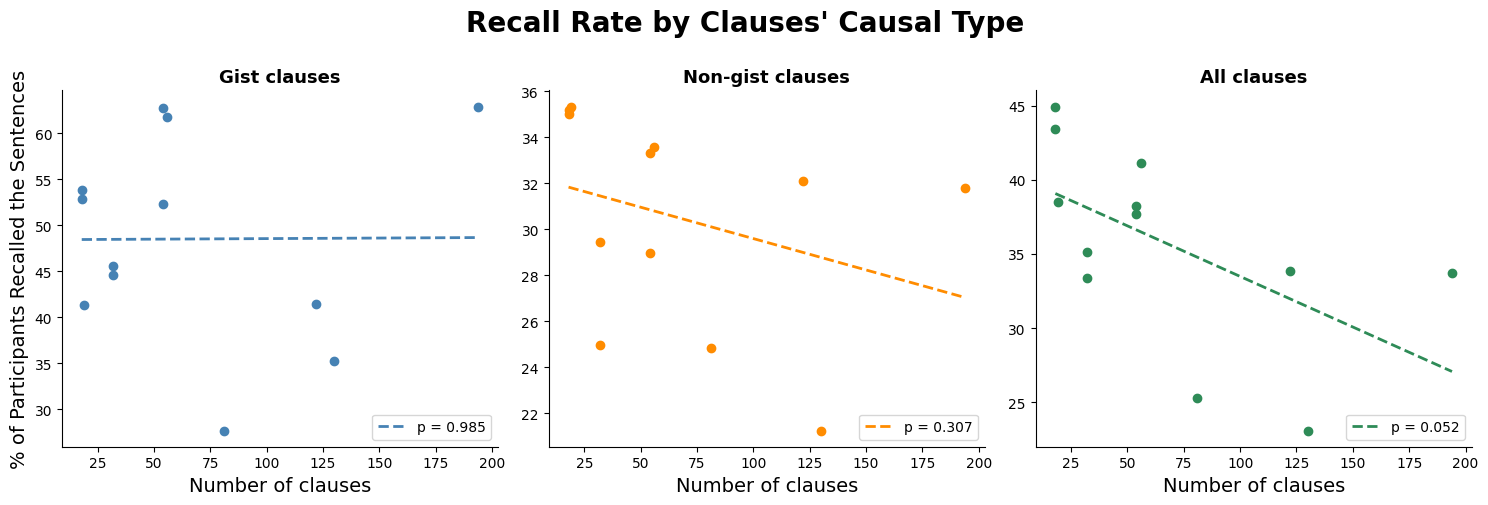

In [11]:
# ── Gather per-story means and stds ──────────────────────────────────────────
recall_mean_gist    = [np.mean(r) for r in recall_percentage_topic]
recall_std_gist     = [np.std(r)  for r in recall_percentage_topic]

recall_mean_nongist = [np.mean(r) for r in recall_percentage_nongist]
recall_std_nongist  = [np.std(r)  for r in recall_percentage_nongist]

recall_mean_all     = [np.mean(r) for r in recall_percentage_all]
recall_std_all      = [np.std(r)  for r in recall_percentage_all]

print("Mean of all clauses:", recall_mean_all)
print("Std of all clauses:", recall_std_all)

x     = np.array(corresponding_clauses)
x_idx = np.arange(len(x))


from scipy.stats import linregress

def reg_line(x, y):
    slope, intercept, r, p, se = linregress(x, y)
    y_hat = slope * x + intercept
    return y_hat, p

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (recall_mean_gist,    recall_std_gist,    "steelblue",  "Gist clauses"),
    (recall_mean_nongist, recall_std_nongist, "darkorange", "Non-gist clauses"),
    (recall_mean_all,     recall_std_all,     "seagreen",   "All clauses"),
]

for i, (ax, (mean, std, color, title)) in enumerate(zip(axes, datasets)):
    y    = np.array(mean)
    yerr = np.array(std)
    y_hat, p = reg_line(x, y)

    p_label = f"p = {p:.3f}" if p > 0.05 else f"p = {p:.3f} *"

    # scatter points with vertical error bars
    # ax.errorbar(x, y, yerr=yerr,
    #             fmt='o', color=color, ecolor=color,
    #             elinewidth=1.5, capsize=5, capthick=1.5,
    #             markersize=6, zorder=3)
    ax.scatter(x, y, color=color, s=36, zorder=3)
    
    # regression line
    sort_idx = np.argsort(x)
    ax.plot(x[sort_idx], y_hat[sort_idx],
            color=color, linewidth=2, linestyle='--', label=p_label, zorder=2)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Number of clauses", fontsize=14)
    
    if i == 0:
        ax.set_ylabel("% of Participants Recalled the Sentences", fontsize=14)
    else:
        ax.set_ylabel("")
        
    ax.legend(fontsize=10, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)
    fig.suptitle("Recall Rate by Clauses' Causal Type", fontsize=20, fontweight='bold', y=1.002)

plt.tight_layout()
plt.savefig("recall_rate_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
from scipy import stats as sp_stats
from scipy.stats import linregress, ttest_rel, f as f_dist
import statsmodels.api as sm
import pandas as pd
import pingouin as pg

x     = np.array(corresponding_clauses, dtype=float)
n     = len(x)
df_r  = n - 2
t_crit = sp_stats.t.ppf(0.975, df_r)

groups = {
    'gist':    np.array(recall_mean_gist),
    'nongist': np.array(recall_mean_nongist),
    'all':     np.array(recall_mean_all),
}

# ═══════════════════════════════════════════════════════
# 1. PER-CURVE REGRESSION STATS
# ═══════════════════════════════════════════════════════
reg_stats = {}
for name, y_arr in groups.items():
    slope, intercept, r_p, p_param, se = linregress(x, y_arr)
    r2       = r_p**2
    cohen_f2 = r2 / (1 - r2 + 1e-10)
    t_obs    = r_p * np.sqrt(df_r) / np.sqrt(1 - r_p**2 + 1e-10)
    power    = (1 - sp_stats.t.cdf(t_crit, df_r, loc=abs(t_obs))
                  + sp_stats.t.cdf(-t_crit, df_r, loc=abs(t_obs)))
    z_r      = np.arctanh(r_p)
    se_z     = 1 / np.sqrt(n - 3)
    ci_r     = [np.tanh(z_r - 1.96*se_z), np.tanh(z_r + 1.96*se_z)]
    X_sm     = sm.add_constant(x)
    m        = sm.OLS(y_arr, X_sm).fit()
    ci_slope = m.conf_int(alpha=0.05)[1]

    reg_stats[name] = dict(slope=slope, intercept=intercept, r=r_p, r2=r2,
                           p=p_param, t=t_obs, f2=cohen_f2, power=power,
                           ci_r=ci_r, ci_slope=ci_slope)

    print(f"\n{'='*55}")
    print(f"  REGRESSION — {name.upper()}")
    print(f"{'='*55}")
    print(f"  slope        = {slope:.4f}  CI=[{ci_slope[0]:.4f}, {ci_slope[1]:.4f}]")
    print(f"  intercept    = {intercept:.4f}")
    print(f"  t({df_r})      = {t_obs:.4f}   p = {p_param:.4e}")
    print(f"  Pearson r    = {r_p:.4f}   CI=[{ci_r[0]:.4f}, {ci_r[1]:.4f}]")
    print(f"  R²           = {r2:.4f}  ({r2*100:.1f}%)")
    print(f"  Cohen's f²   = {cohen_f2:.4f}  ({'small' if cohen_f2<0.15 else 'medium' if cohen_f2<0.35 else 'large'})")
    print(f"  Power        = {power:.4f}")

# ═══════════════════════════════════════════════════════
# 2. REPEATED MEASURES ANOVA
# ═══════════════════════════════════════════════════════
df_long = pd.DataFrame({
    'story':     list(range(n)) * 3,
    'condition': ['gist']*n + ['nongist']*n + ['all']*n,
    'recall':    list(groups['gist']) + list(groups['nongist']) + list(groups['all'])
})

rm_anova = pg.rm_anova(data=df_long, dv='recall', within='condition', subject='story', detailed=True)
print(f"\n{'='*55}")
print("  REPEATED MEASURES ANOVA")
print(f"{'='*55}")
print(rm_anova[['Source','F','p-unc','ng2','eps']].to_string(index=False))

# ── post-hoc paired t-tests with FDR ──
pairs   = [('gist','nongist'), ('gist','all'), ('nongist','all')]
p_vals  = []
t_vals  = []
for a, b in pairs:
    t_, p_ = ttest_rel(groups[a], groups[b])
    t_vals.append(t_)
    p_vals.append(p_)

from statsmodels.stats.multitest import multipletests
reject, p_fdr, _, _ = multipletests(p_vals, method='fdr_bh')

print(f"\n  POST-HOC (paired t-test, FDR corrected)")
print(f"  {'Pair':<20} {'t':>7} {'p_raw':>8} {'p_fdr':>8} {'sig':>5}")
for (a, b), t_, p_r, p_f, rej in zip(pairs, t_vals, p_vals, p_fdr, reject):
    d     = (groups[a] - groups[b])
    cohd  = d.mean() / d.std(ddof=1)
    print(f"  {a} vs {b:<12} {t_:>7.3f} {p_r:>8.4f} {p_f:>8.4f} {'*' if rej else '':>5}  d={cohd:.3f}")

# ═══════════════════════════════════════════════════════
# 3. PERMUTATION TEST — per curve + ANOVA F
# ═══════════════════════════════════════════════════════
n_perm = 10000
print(f"\n{'='*55}")
print(f"  PERMUTATION (n={n_perm})")
print(f"{'='*55}")

for name, y_arr in groups.items():
    r_obs  = linregress(x, y_arr)[2]
    r_perm = [linregress(np.random.permutation(x), y_arr)[2] for _ in range(n_perm)]
    p_perm = np.mean(np.abs(r_perm) >= np.abs(r_obs))
    print(f"  {name:<10} r={r_obs:.4f}  p_perm={p_perm:.4f}")

# permutation on ANOVA F
f_obs  = rm_anova['F'].values[0]
f_perm = []
for _ in range(n_perm):
    df_shuf = df_long.copy()
    df_shuf['recall'] = np.random.permutation(df_shuf['recall'].values)
    try:
        res = pg.rm_anova(data=df_shuf, dv='recall', within='condition',
                          subject='story', detailed=False)
        f_perm.append(res['F'].values[0])
    except Exception:
        continue
p_perm_anova = np.mean(np.array(f_perm) >= f_obs)
print(f"\n  ANOVA F_obs={f_obs:.4f}  p_perm={p_perm_anova:.4f}")

# ═══════════════════════════════════════════════════════
# 4. BOOTSTRAP — per curve
# ═══════════════════════════════════════════════════════
n_boot = 10000
print(f"\n{'='*55}")
print(f"  BOOTSTRAP (n={n_boot})")
print(f"{'='*55}")

for name, y_arr in groups.items():
    r_boot, sl_boot, r2_boot, t_boot = [], [], [], []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        xb, yb = x[idx], y_arr[idx]
        if len(np.unique(xb)) < 2:
            continue
        sl, ic, r_, _, _ = linregress(xb, yb)
        r_boot.append(r_)
        sl_boot.append(sl)
        r2_boot.append(r_**2)
        t_boot.append(r_ * np.sqrt(n-2) / np.sqrt(1 - r_**2 + 1e-10))

    r_boot  = np.array(r_boot)
    sl_boot = np.array(sl_boot)
    r2_boot = np.array(r2_boot)
    t_boot  = np.array(t_boot)
    p_boot  = 2 * min(np.mean(r_boot <= 0), np.mean(r_boot >= 0))
    pow_b   = np.mean(np.abs(t_boot) >= t_crit)
    f2_boot = np.mean(r2_boot) / (1 - np.mean(r2_boot) + 1e-10)

    print(f"\n  {name.upper()}")
    print(f"    p              = {p_boot:.4f}")
    print(f"    slope          = {np.mean(sl_boot):.4f}  CI=[{np.percentile(sl_boot,2.5):.4f}, {np.percentile(sl_boot,97.5):.4f}]")
    print(f"    r              = {np.mean(r_boot):.4f}  CI=[{np.percentile(r_boot,2.5):.4f}, {np.percentile(r_boot,97.5):.4f}]")
    print(f"    R²             = {np.mean(r2_boot):.4f}  CI=[{np.percentile(r2_boot,2.5):.4f}, {np.percentile(r2_boot,97.5):.4f}]")
    print(f"    Cohen's f²     = {f2_boot:.4f}")
    print(f"    Power          = {pow_b:.4f}")



  REGRESSION — GIST
  slope        = 0.0012  CI=[-0.1422, 0.1446]
  intercept    = 48.4289
  t(10)      = 0.0188   p = 9.8537e-01
  Pearson r    = 0.0059   CI=[-0.5699, 0.5779]
  R²           = 0.0000  (0.0%)
  Cohen's f²   = 0.0000  (small)
  Power        = 0.0500

  REGRESSION — NONGIST
  slope        = -0.0273  CI=[-0.0837, 0.0292]
  intercept    = 32.3224
  t(10)      = -1.0763   p = 3.0706e-01
  Pearson r    = -0.3222   CI=[-0.7563, 0.3088]
  R²           = 0.1038  (10.4%)
  Cohen's f²   = 0.1159  (small)
  Power        = 0.1421

  REGRESSION — ALL
  slope        = -0.0682  CI=[-0.1371, 0.0006]
  intercept    = 40.3037
  t(10)      = -2.2083   p = 5.1705e-02
  Pearson r    = -0.5725   CI=[-0.8629, 0.0020]
  R²           = 0.3278  (32.8%)
  Cohen's f²   = 0.4877  (large)
  Power        = 0.4929

  REPEATED MEASURES ANOVA
   Source         F        p-unc      ng2      eps
condition 36.193866 1.103007e-07 0.496696 0.587023
    Error       NaN          NaN      NaN      NaN

  POST-H

In [41]:
## ── regenerate recall_percentage_* with per-participant tracking ──────────
model = SentenceTransformer('all-MiniLM-L6-v2')

distance_threshold = 1 - math.cos(math.radians(60))

index_main_all = [
    index_main_story_1,  index_main_story_2,  index_main_story_3,
    index_main_story_4,  index_main_story_5,  index_main_story_6,
    index_main_story_7,  index_main_story_8,  index_main_story_9,
    index_main_story_10, index_main_story_11, index_main_story_12,
]

topic_clauses_all          = []
non_gist_clauses_all       = []
recall_percentage_topic    = []
recall_percentage_nongist  = []
recall_percentage_all      = []

# NEW: per-participant rates (fraction 0-1), one array per story
recall_percentage_topic_participant   = []
recall_percentage_nongist_participant = []
recall_percentage_all_participant     = []

for i in range(12):
    index_main   = set(index_main_all[i])
    all_indices  = set(range(1, clauses[i] + 1))

    topic_clauses    = [story_processed_all[i][j-1] for j in index_main_all[i]]
    non_gist_clauses = [story_processed_all[i][j-1] for j in all_indices if j not in index_main]

    topic_emb    = [model.encode(c) for c in topic_clauses]
    non_gist_emb = [model.encode(c) for c in non_gist_clauses]
    all_emb      = topic_emb + non_gist_emb

    recall_emb = [
        [model.encode(c) for c in recall_processed_all[i][p]]
        for p in range(len(recall_processed_all[i]))
    ]
    n_participants = len(recall_emb)

    def recall_rate_with_participants(clause_embs):
        n_clauses = len(clause_embs)
        # participant x clause matrix of 0/1 recall indicators
        recall_matrix = np.zeros((n_participants, n_clauses))
        for idx, clause in enumerate(clause_embs):
            for p_idx, participant in enumerate(recall_emb):
                if any(cosine(clause, r) < distance_threshold for r in participant):
                    recall_matrix[p_idx, idx] = 1.0

        clause_pct        = (100 * recall_matrix.mean(axis=0)).tolist()   # per-clause %, same as before
        participant_rates = recall_matrix.mean(axis=1).tolist()          # per-participant fraction (0-1)
        return clause_pct, participant_rates

    topic_pct,    topic_participant_rates    = recall_rate_with_participants(topic_emb)
    nongist_pct,  nongist_participant_rates  = recall_rate_with_participants(non_gist_emb)
    all_pct,      all_participant_rates      = recall_rate_with_participants(all_emb)

    topic_clauses_all.append(topic_clauses)
    non_gist_clauses_all.append(non_gist_clauses)

    recall_percentage_topic.append(topic_pct)
    recall_percentage_nongist.append(nongist_pct)
    recall_percentage_all.append(all_pct)

    recall_percentage_topic_participant.append(topic_participant_rates)
    recall_percentage_nongist_participant.append(nongist_participant_rates)
    recall_percentage_all_participant.append(all_participant_rates)

    print(f"Story {i+1} done — {len(topic_clauses)} topic, "
          f"{len(non_gist_clauses)} non-gist, {n_participants} participants")
    print(f"  topic recall %: {[round(v,1) for v in recall_percentage_topic[-1]]}")



Story 1 done — 10 topic, 9 non-gist, 100 participants
  topic recall %: [83.0, 62.0, 54.0, 39.0, 24.0, 4.0, 40.0, 31.0, 25.0, 51.0]
Story 2 done — 12 topic, 6 non-gist, 56 participants
  topic recall %: [87.5, 5.4, 87.5, 58.9, 23.2, 60.7, 14.3, 42.9, 41.1, 58.9, 26.8, 64.3]
Story 3 done — 10 topic, 8 non-gist, 100 participants
  topic recall %: [89.0, 2.0, 95.0, 73.0, 40.0, 53.0, 24.0, 96.0, 35.0, 22.0]
Story 4 done — 11 topic, 21 non-gist, 100 participants
  topic recall %: [78.0, 62.0, 63.0, 21.0, 10.0, 5.0, 74.0, 41.0, 87.0, 28.0, 34.0]
Story 5 done — 13 topic, 19 non-gist, 101 participants
  topic recall %: [87.1, 77.2, 30.7, 10.9, 51.5, 53.5, 56.4, 11.9, 41.6, 49.5, 59.4, 33.7, 29.7]
Story 6 done — 15 topic, 41 non-gist, 100 participants
  topic recall %: [51.0, 25.0, 70.0, 62.0, 71.0, 57.0, 47.0, 32.0, 78.0, 92.0, 89.0, 62.0, 79.0, 82.0, 29.0]
Story 7 done — 14 topic, 40 non-gist, 98 participants
  topic recall %: [44.9, 34.7, 33.7, 38.8, 54.1, 73.5, 71.4, 77.6, 21.4, 51.0, 74.5,

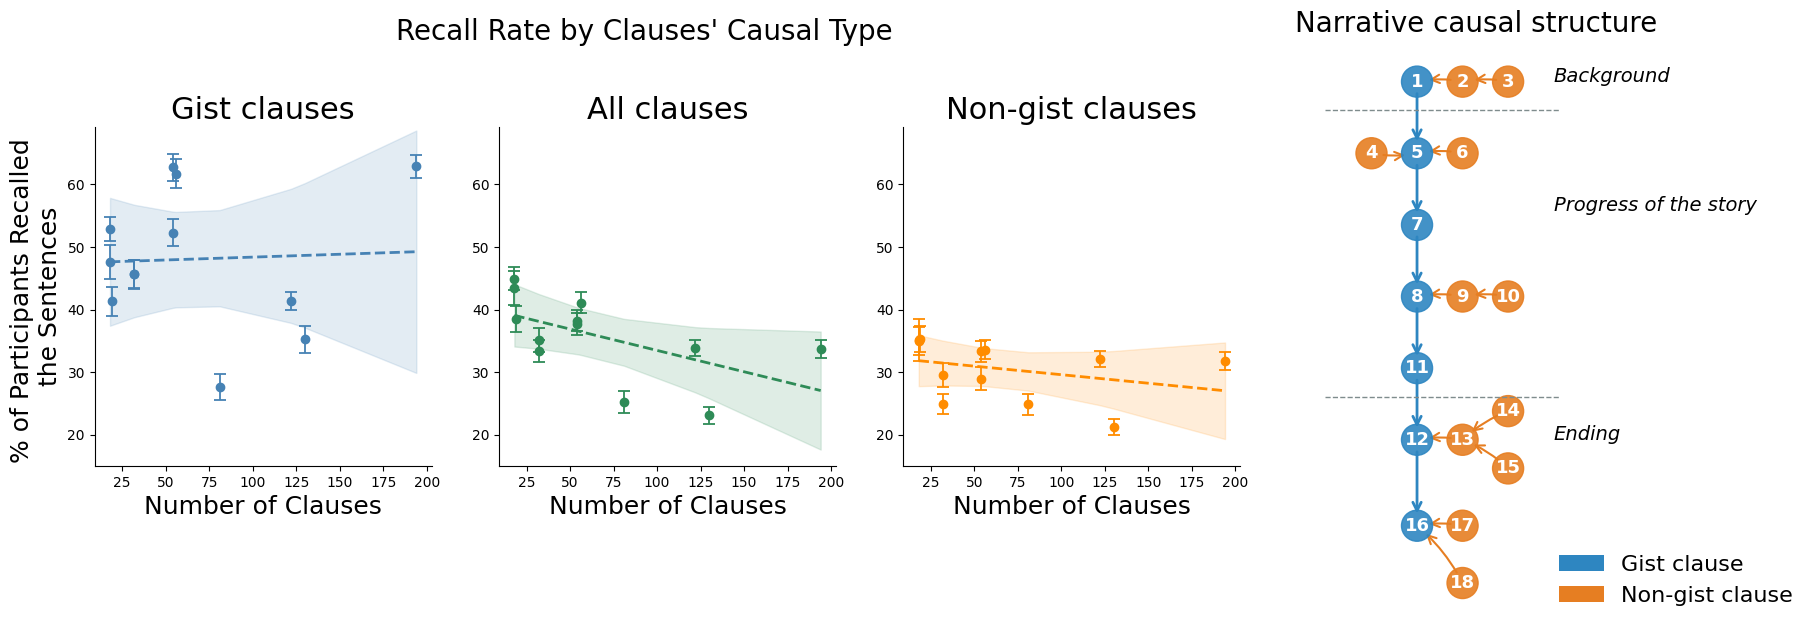

In [42]:
import matplotlib.gridspec as gridspec
import networkx as nx

# datasets now carries SE computed across participants (n = n_participants),
# not across clauses
def mean_and_se_from_participants(participant_list):
    # participant_list[i] = array of per-participant fractions (0-1) for story i
    means = [100 * np.mean(p) for p in participant_list]
    ses   = [100 * np.std(p, ddof=1) / np.sqrt(len(p)) for p in participant_list]
    return means, ses

recall_mean_gist,    recall_se_gist    = mean_and_se_from_participants(recall_percentage_topic_participant)
recall_mean_nongist, recall_se_nongist = mean_and_se_from_participants(recall_percentage_nongist_participant)
recall_mean_all,     recall_se_all     = mean_and_se_from_participants(recall_percentage_all_participant)

datasets = [
    (recall_mean_gist,    recall_se_gist,    "steelblue",  "Gist clauses"),
    (recall_mean_nongist, recall_se_nongist, "darkorange", "Non-gist clauses"),
    (recall_mean_all,     recall_se_all,     "seagreen",   "All clauses"),
]

fig = plt.figure(figsize=(20, 8))
gs  = gridspec.GridSpec(1, 4, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])

axes = [ax1, ax2, ax3, ax4]

# reorder: gist / all clauses / non-gist
datasets_ordered = [datasets[0], datasets[2], datasets[1]]

# ── collect y range across all three panels ───────────────────────────────────
all_y_vals = []
for mean, se, color, title in datasets_ordered:
    all_y_vals.extend(np.array(mean).tolist())
y_min = np.nanmin(all_y_vals)
y_max = np.nanmax(all_y_vals)
y_pad = (y_max - y_min) * 0.15
y_lim = (max(0, y_min - y_pad), y_max + y_pad)

# ── first three scatter panels ────────────────────────────────────────────────
x_arr    = np.array(x)
x_sorted = np.sort(x_arr)
X_fit    = sm.add_constant(x_sorted)

for i, (ax, (mean, se, color, title)) in enumerate(zip(axes[:3], datasets_ordered)):
    y      = np.array(mean)
    yerr   = np.array(se)
    X      = sm.add_constant(x_arr)
    m      = sm.OLS(y, X).fit()
    iv, sl = m.params
    p      = m.pvalues[1]
    y_hat  = iv + sl * x_sorted

    pred  = m.get_prediction(X_fit)
    ci    = pred.conf_int(alpha=0.05)

    ax.errorbar(x_arr, y, yerr=yerr,
                fmt='o', color=color, ecolor=color,
                elinewidth=1.3, capsize=4, capthick=1.3,
                markersize=6, zorder=3)
    ax.plot(x_sorted, y_hat, color=color, linewidth=2, linestyle='--', zorder=2)
    ax.fill_between(x_sorted, ci[:, 0], ci[:, 1],
                    color=color, alpha=0.15, zorder=1, label='95% CI')

    ax.set_ylim(y_lim)
    ax.set_title(title, fontsize=22)
    ax.set_xlabel("Number of Clauses", fontsize=18)
    ax.set_ylabel("% of Participants Recalled \nthe Sentences", fontsize=18) \
        if i == 0 else ax.set_ylabel("")
    ax.spines[['top', 'right']].set_visible(False)

# ── fourth panel: network graph ───────────────────────────────────────────────
nodes_story_short = list(np.arange(1, len(story_processed_all[1]) + 1))
G = nx.DiGraph()
G.add_nodes_from(nodes_story_short)

side_edges = [(2, 1), (3, 2), (4, 5), (6, 5), (9, 8), (10, 9),
              (13, 12), (14, 13), (15, 13), (17, 16), (18, 16)]
main_edges = [(1, 5), (5, 7), (7, 8), (8, 11), (11, 12), (12, 16)]

G.add_edges_from(side_edges + main_edges)

# tighter vertical spacing
node_pos = {
    1:  (0,    0),   5:  (0,   -5),   7:  (0,  -10),
    8:  (0,  -15),  11:  (0,  -20),  12:  (0,  -25),  16: (0,  -31),
    2:  (0.5,   0),  3:  (1,     0),   4: (-0.5,  -5),  6: (0.5,  -5),
    9:  (0.5, -15), 10:  (1,   -15),  13: (0.5,  -25),
    14: (1,   -23), 15:  (1,   -27),
    17: (0.5, -31), 18:  (0.5, -35),
}

main_nodes = {1, 5, 7, 8, 11, 12, 16}
main_color = '#2e86c1'
side_color = '#e67e22'

node_colors = [main_color if n in main_nodes else side_color for n in G.nodes()]

nx.draw_networkx_nodes(G, node_pos, ax=ax4, node_color=node_colors,
                       node_size=500, alpha=0.9)
nx.draw_networkx_labels(G, node_pos, ax=ax4, font_size=13,
                        font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, node_pos, edgelist=main_edges, ax=ax4,
                       edge_color=main_color, arrows=True,
                       arrowstyle='->', arrowsize=15, width=2.0,
                       connectionstyle='arc3,rad=0.0')
nx.draw_networkx_edges(G, node_pos, edgelist=side_edges, ax=ax4,
                       edge_color=side_color, arrows=True,
                       arrowstyle='->', arrowsize=15, width=1.5,
                       connectionstyle='arc3,rad=0.1')

annot_color = '#7f8c8d'
ax4.text(1.5,  0,   "Background",            fontsize=14, color='black', style='italic')
ax4.text(1.5,  -9,  "Progress of the story", fontsize=14, color='black', style='italic')
ax4.text(1.5, -25,  "Ending",                fontsize=14, color='black', style='italic')
ax4.axhline(y=-2,  color=annot_color, linestyle='--', linewidth=1, xmin=0.05, xmax=0.75)
ax4.axhline(y=-22, color=annot_color, linestyle='--', linewidth=1, xmin=0.05, xmax=0.75)

# legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=main_color, label='Gist clause'),
    Patch(facecolor=side_color, label='Non-gist clause'),
]
ax4.legend(handles=legend_handles, fontsize=16, loc='lower right',
           frameon=False, bbox_to_anchor=(1.5, 0.0))

ax4.set_title("Narrative causal structure", fontsize=20, y=0.95)
ax4.set_ylim(-38, 5)
ax4.set_xlim(-1.2, 2.5)
ax4.axis('off')

# ── layout adjustment — shorter height ────────────────────────────────────────
for ax in [ax1, ax2, ax3]:
    ax_pos = ax.get_position()
    ax.set_position([ax_pos.x0, ax_pos.y0 + 0.2, ax_pos.width, ax_pos.height * 0.55])

fig.suptitle("Recall Rate by Clauses' Causal Type", fontsize=20, y=0.87, x=0.4)

plt.savefig("recall_rate_scatter.png", dpi=150, bbox_inches='tight')
plt.show()


In [32]:
import pingouin as pg

df_long = pd.DataFrame({
    'narrative': list(range(12)) * 3,
    'condition': ['Gist'] * 12 + ['Non-gist'] * 12 + ['All'] * 12,
    'recall':    list(recall_mean_gist) + list(recall_mean_nongist) + list(recall_mean_all)
})

# ── repeated measures ANOVA ───────────────────────────────────────────────────
rm = pg.rm_anova(data=df_long, dv='recall', within='condition', subject='narrative', detailed=True)
print("── Repeated Measures ANOVA ──────────────────────────────")
print(rm[['Source', 'SS', 'F', 'p-unc', 'ng2']].to_string(index=False))

# ── post-hoc paired t-tests with Bonferroni correction ───────────────────────
posthoc = pg.pairwise_tests(data=df_long, dv='recall', within='condition',
                             subject='narrative', padjust='bonf')
print("\n── Post-hoc Pairwise Tests ───────────────────────────────")
print(posthoc[['A', 'B', 'T', 'p-unc', 'p-corr', 'hedges']].to_string(index=False))

── Repeated Measures ANOVA ──────────────────────────────
   Source          SS         F        p-unc      ng2
condition 2065.541731 36.193866 1.103007e-07 0.496696
    Error  627.757167       NaN          NaN      NaN

── Post-hoc Pairwise Tests ───────────────────────────────
   A        B         T    p-unc   p-corr    hedges
 All     Gist -5.352626 0.000233 0.000699 -1.347406
 All Non-gist  5.441412 0.000203 0.000610  0.885274
Gist Non-gist  6.531536 0.000042 0.000127  2.028679


In [33]:
## calculate the mean value of the three recall rates.
print(f"Gist mean:     {np.mean(recall_mean_gist):.2f}%")
print(f"Non-gist mean: {np.mean(recall_mean_nongist):.2f}%")
print(f"All mean:      {np.mean(recall_mean_all):.2f}%")


Gist mean:     48.51%
Non-gist mean: 30.48%
All mean:      35.70%


## Compare GPT and manual results.

p-value: 0.1602788466899814


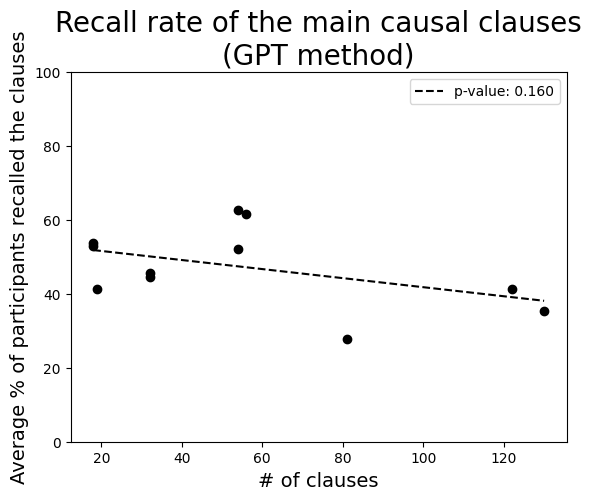

In [34]:
# plot.
clauses_arr = np.array(clauses)
recall_arr  = np.array(recall_percentage_main_clause)
mask        = clauses_arr != 194
x_plot      = clauses_arr[mask]
y_plot      = recall_arr[mask]

X   = sm.add_constant(x_plot)
ols = sm.OLS(y_plot, X).fit()
intercept, slope = ols.params
p_value = ols.pvalues[1]
print("p-value:", p_value)

x_regression = np.linspace(min(x_plot), max(x_plot), 10)
y_regression = intercept + slope * x_regression

plt.scatter(x_plot, y_plot, color="black")
plt.plot(x_regression, y_regression, "--", color="black", label=f"p-value: {p_value:.3f}")
plt.title("Recall rate of the main causal clauses\n(GPT method)", fontsize=20)
plt.xlabel("# of clauses", fontsize=14)
plt.ylabel("Average % of participants recalled the clauses", fontsize=14)
plt.ylim([0, 100])
plt.legend()
plt.show()


## Manual gist comparison.

In [35]:
manual_index_main_story_1 = [1, 2, 7, 8, 9, 13, 17]
manual_index_main_story_2 = [1, 5, 7, 8, 11, 12, 16]  
manual_index_main_story_3 = [1, 5, 7, 11, 13, 15, 16]  

manual_index_main_story_4 = [1, 4, 12, 13, 16, 20, 24, 26, 28, 30] 
manual_index_main_story_5 = [1, 4, 5, 12, 13, 16, 20, 22, 23, 25, 27]  

manual_index_main_story_6 = [1, 6, 8, 15, 17, 18, 20, 23, 28, 34, 35, 37, 39, 40, 44, 47, 49, 54] 
manual_index_main_story_7 = [1, 5, 10, 11, 13, 14, 18, 21, 22, 29, 35, 40, 42, 46, 49, 53] 
manual_index_main_story_8 = [4, 5, 10, 15, 19, 24, 31, 36, 40, 44, 46, 53]  

manual_index_main_story_9 = [1, 5, 10, 11, 14, 17, 27, 33, 36, 40, 45, 51, 52, 55, 61, 66, 74, 77, 84, 86, 92, 96, 103, 106, 115, 122, 126] 
manual_index_main_story_10 = [1, 11, 12, 15, 19, 29, 32, 35, 39, 41, 48, 57, 71, 75, 77, 80, 84, 87, 90, 95, 97, 99, 105, 107, 110, 113, 115, 120, 122] 
manual_index_main_story_11 = [1, 4, 5, 7, 19, 21, 24, 27, 128, 163, 166, 190]
manual_index_main_story_12 = [1, 4, 7, 9, 13, 15, 20,  23, 25, 28, 32, 35, 38, 42, 47, 59, 64, 70, 72, 76, 79, 81]

manual_indices_all = [
    manual_index_main_story_1,  manual_index_main_story_2,
    manual_index_main_story_3,  manual_index_main_story_4,
    manual_index_main_story_5,  manual_index_main_story_6,
    manual_index_main_story_7,  manual_index_main_story_8,
    manual_index_main_story_9,  manual_index_main_story_10,
    manual_index_main_story_11, manual_index_main_story_12,
]


In [36]:
model = SentenceTransformer('all-MiniLM-L6-v2')

recall_emb_all = []
gist_manual_emb = []

for s in range(len(recall_processed_all)):
    story_embs = []
    for p in range(len(recall_processed_all[s])):
        texts = recall_processed_all[s][p]
        if len(texts) == 0:
            story_embs.append(np.array([]))
        else:
            emb = np.array(model.encode(texts))
            story_embs.append(emb)
    recall_emb_all.append(story_embs)

    gist_indices = manual_indices_all[s]
    texts = [story_processed_all[s][i - 1] for i in gist_indices]
    emb   = np.array(model.encode(texts))
    gist_manual_emb.append(emb)

    print(f"Story {s+1} done — gist shape: {emb.shape}")


Story 1 done — gist shape: (7, 384)
Story 2 done — gist shape: (7, 384)
Story 3 done — gist shape: (7, 384)
Story 4 done — gist shape: (10, 384)
Story 5 done — gist shape: (11, 384)
Story 6 done — gist shape: (18, 384)
Story 7 done — gist shape: (16, 384)
Story 8 done — gist shape: (12, 384)
Story 9 done — gist shape: (27, 384)
Story 10 done — gist shape: (29, 384)
Story 11 done — gist shape: (12, 384)
Story 12 done — gist shape: (22, 384)


In [37]:
threshold = 0.5   # cosine distance for 60°

recall_percentage_manual = []

for s in range(12):
    # if s == 10 or len(gist_manual_emb[s]) == 0 or len(recall_emb_all[s]) == 0:
    #     recall_percentage_manual.append(np.nan)
    #     print(f"Story {s+1} skipped")
    #     continue

    n_participants = len(recall_emb_all[s])

    clause_rates = []
    for clause_emb in gist_manual_emb[s]:
        clause_norm = clause_emb / np.linalg.norm(clause_emb)

        recalled, valid = 0, 0
        for p in range(n_participants):
            r_embs = np.array(recall_emb_all[s][p])
            if len(r_embs) == 0:
                continue
            valid += 1
            r_norms   = r_embs / np.linalg.norm(r_embs, axis=1, keepdims=True)
            cos_dists = 1 - r_norms @ clause_norm
            if np.any(cos_dists <= threshold):
                recalled += 1

        if valid > 0:
            clause_rates.append(recalled / valid * 100)

    recall_percentage_manual.append(np.mean(clause_rates))
    print(f"Story {s+1}: {recall_percentage_manual[-1]:.2f}%")


Story 1: 46.71%
Story 2: 62.50%
Story 3: 70.29%
Story 4: 56.60%
Story 5: 43.20%
Story 6: 51.94%
Story 7: 50.57%
Story 8: 62.83%
Story 9: 32.70%
Story 10: 54.31%
Story 11: 62.90%
Story 12: 31.77%


p-value: 0.08804006632493352


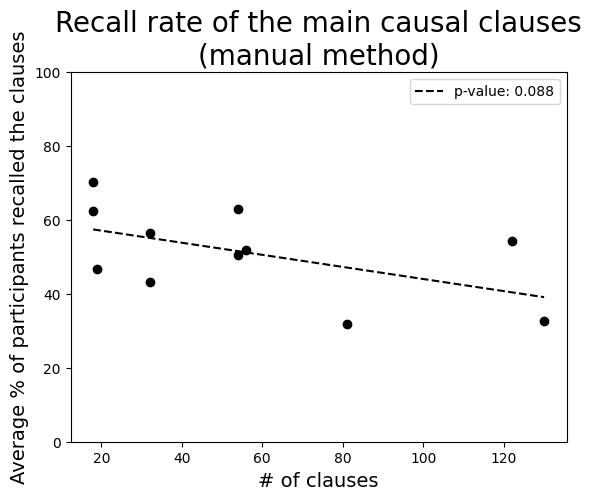

In [38]:
clause_arr = np.array(clauses[0:12])
recall_arr = np.array(recall_percentage_manual)
mask       = clause_arr != 194
x_plot     = clause_arr[mask]
y_plot     = recall_arr[mask]

X         = sm.add_constant(x_plot)
model_fit = sm.OLS(y_plot, X).fit()
intercept, slope = model_fit.params
p_value = model_fit.pvalues[1]
print("p-value:", p_value)

x_regression = np.linspace(x_plot.min(), x_plot.max(), 10)
y_regression = intercept + slope * x_regression

plt.scatter(x_plot, y_plot, color="black")
plt.plot(x_regression, y_regression, "--", color="black", label=f"p-value: {p_value:.3f}")
plt.title("Recall rate of the main causal clauses\n(manual method)", fontsize=20)
plt.xlabel("# of clauses", fontsize=14)
plt.ylabel("Average % of participants recalled the clauses", fontsize=14)
plt.ylim([0, 100])
plt.legend()
plt.show()



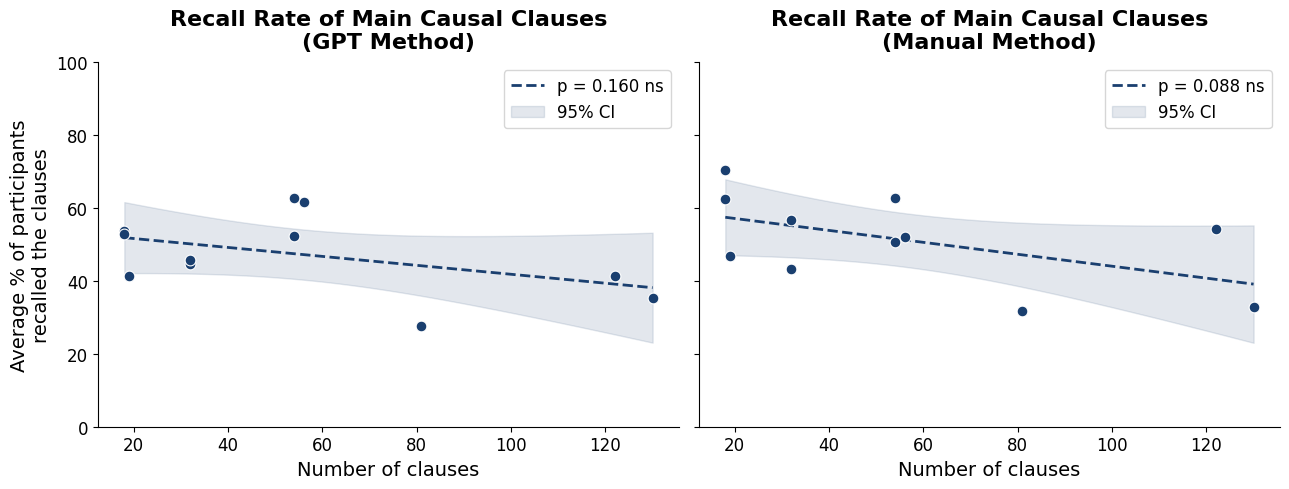

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

dot_color  = '#1a3f6f'
line_color = '#1a3f6f'

def plot_panel(ax, x_plot, y_plot, ols, title, show_ylabel):
    intercept, slope = ols.params
    p_value          = ols.pvalues[1]
    x_fine           = np.linspace(x_plot.min(), x_plot.max(), 300)
    pred             = ols.get_prediction(sm.add_constant(x_fine)).summary_frame(alpha=0.05)
    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    ax.scatter(x_plot, y_plot, color=dot_color, s=60, zorder=3,
               edgecolors='white', linewidths=0.8)
    ax.plot(x_fine, intercept + slope * x_fine, '--', color=line_color, lw=2,
            label=f"p = {p_value:.3f} {sig}")
    ax.fill_between(x_fine, pred['mean_ci_lower'], pred['mean_ci_upper'],
                    color=line_color, alpha=0.12, label='95% CI')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel("Number of clauses", fontsize=14)
    if show_ylabel:
        ax.set_ylabel("Average % of participants\nrecalled the clauses", fontsize=14)
    ax.set_ylim([0, 100])
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)

# ── GPT method ────────────────────────────────────────────────────────────────
clauses_arr = np.array(clauses)
mask        = clauses_arr != 194
x1          = clauses_arr[mask]
y1          = np.array(recall_percentage_main_clause)[mask]
ols1        = sm.OLS(y1, sm.add_constant(x1)).fit()
plot_panel(ax1, x1, y1, ols1, "Recall Rate of Main Causal Clauses\n(GPT Method)", show_ylabel=True)

# ── Manual method ─────────────────────────────────────────────────────────────
clause_arr = np.array(clauses[0:12])
mask       = clause_arr != 194
x2         = clause_arr[mask]
y2         = np.array(recall_percentage_manual)[mask]
ols2       = sm.OLS(y2, sm.add_constant(x2)).fit()
plot_panel(ax2, x2, y2, ols2, "Recall Rate of Main Causal Clauses\n(Manual Method)", show_ylabel=False)

plt.tight_layout()
plt.savefig("recall_rate_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


In [40]:
from scipy import stats

data01 = {
    'x': [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 81],
    'y': [41.3, 53.79, 52.9, 44.58, 45.62, 61.73, 52.26, 62.71, 35.23, 41.39, 27.69]
}

data02 = {
    'x': [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 81],
    'y': [46.71, 62.5, 70.29, 56.6, 43.2, 51.94, 50.57, 62.83, 32.7, 54.31, 31.77]
}

# drop x=194 from data01 to match data02
x01 = np.array(data01['x'])
y01 = np.array(data01['y'])
mask = x01 != 194
y01_matched = y01[mask]
y02_matched = np.array(data02['y'])

print(f"n = {len(y01_matched)}")
t_stat, p_value = stats.ttest_rel(y01_matched, y02_matched)
print(f"t = {t_stat:.4f},  p = {p_value:.4f}")
print(f"mean data01 = {y01_matched.mean():.2f},  mean data02 = {y02_matched.mean():.2f}")


n = 11
t = -1.6303,  p = 0.1341
mean data01 = 47.20,  mean data02 = 51.22


In [41]:
from scipy import stats
from scipy.stats import t as sp_t, nct as sp_nct, pearsonr
from sklearn.metrics import cohen_kappa_score
import pingouin as pg
import numpy as np
import pandas as pd

x01 = np.array(data01['x'])
y01 = np.array(data01['y'])
mask         = x01 != 194
y01_matched  = y01[mask]
y02_matched  = np.array(data02['y'])
n            = len(y01_matched)
diff         = y01_matched - y02_matched

# ── paired t-test ─────────────────────────────────────────────────────────────
t_stat, p_ttest = stats.ttest_rel(y01_matched, y02_matched)
se_diff  = np.std(diff, ddof=1) / np.sqrt(n)
ci_diff  = stats.t.interval(0.95, df=n-1, loc=np.mean(diff), scale=se_diff)
cohen_d  = np.mean(diff) / np.std(diff, ddof=1)

# ── power ─────────────────────────────────────────────────────────────────────
ncp     = cohen_d * np.sqrt(n)
t_crit  = sp_t.ppf(0.975, df=n-1)
power   = 1 - sp_nct.cdf(t_crit, n-1, ncp) + sp_nct.cdf(-t_crit, n-1, ncp)

# ── Pearson correlation ───────────────────────────────────────────────────────
r_pearson, p_pearson = pearsonr(y01_matched, y02_matched)

# ── permutation test ──────────────────────────────────────────────────────────
n_perm   = 10000
t_obs    = t_stat
perm_t   = [stats.ttest_rel(
                y01_matched * s, y02_matched * s)[0]
            for s in [np.random.choice([-1,1], n) for _ in range(n_perm)]]
p_perm   = np.mean(np.abs(perm_t) >= np.abs(t_obs))

# ── bootstrap ─────────────────────────────────────────────────────────────────
n_boot = 10000
t_boot, d_boot = [], []
for _ in range(n_boot):
    idx  = np.random.choice(n, n, replace=True)
    d_i  = y01_matched[idx] - y02_matched[idx]
    t_i  = np.mean(d_i) / (np.std(d_i, ddof=1) / np.sqrt(n))
    t_boot.append(t_i)
    d_boot.append(np.mean(d_i) / np.std(d_i, ddof=1))
t_boot = np.array(t_boot)
d_boot = np.array(d_boot)
p_boot = 2 * min(np.mean(t_boot <= 0), np.mean(t_boot >= 0))

# ── ICC (appropriate for continuous ratings) ──────────────────────────────────
df_icc = pd.DataFrame({
    'targets': list(range(n)) * 2,
    'raters':  ['rater1']*n + ['rater2']*n,
    'scores':  list(y01_matched) + list(y02_matched)
})
icc_res = pg.intraclass_corr(data=df_icc, targets='targets',
                              raters='raters', ratings='scores')
icc2    = icc_res[icc_res['Type']=='ICC2'].iloc[0]

# ── Cohen's κ (binarized at median) ──────────────────────────────────────────
median_threshold = np.median(np.concatenate([y01_matched, y02_matched]))
k1   = (y01_matched >= median_threshold).astype(int)
k2   = (y02_matched >= median_threshold).astype(int)
kappa = cohen_kappa_score(k1, k2)

# ── report ────────────────────────────────────────────────────────────────────
def sig(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

print("=" * 60)
print(f"  Inter-rater statistics  (n = {n} matched stories)")
print("=" * 60)
print(f"  mean rater1              = {y01_matched.mean():.2f}")
print(f"  mean rater2              = {y02_matched.mean():.2f}")
print(f"  mean difference          = {np.mean(diff):.2f}")
print(f"  95% CI of difference     = [{ci_diff[0]:.2f}, {ci_diff[1]:.2f}]")
print()
print(f"  [Paired t-test]")
print(f"  t({n-1})                  = {t_stat:.4f}")
print(f"  p (parametric)           = {p_ttest:.4e}  {sig(p_ttest)}")
print(f"  Cohen's d                = {cohen_d:.4f}")
print(f"  power                    = {power:.4f}")
print()
print(f"  [Pearson r]")
print(f"  r                        = {r_pearson:.4f}")
print(f"  p                        = {p_pearson:.4e}  {sig(p_pearson)}")
print()
print(f"  [Permutation test]  (n={n_perm:,})")
print(f"  p                        = {p_perm:.4f}  {sig(p_perm)}")
print()
print(f"  [Bootstrap]  (n={n_boot:,})")
print(f"  mean d                   = {d_boot.mean():.4f}")
print(f"  95% CI of d              = [{np.percentile(d_boot,2.5):.4f}, {np.percentile(d_boot,97.5):.4f}]")
print(f"  p                        = {p_boot:.4f}  {sig(p_boot)}")
print()
print(f"  [ICC2 — consistency]")
print(f"  ICC                      = {icc2['ICC']:.4f}")
print(f"  95% CI                   = [{icc2['CI95%'][0]:.4f}, {icc2['CI95%'][1]:.4f}]")
print(f"  p                        = {icc2['pval']:.4e}  {sig(icc2['pval'])}")
print()
print(f"  [Cohen's κ — binarized at median={median_threshold:.1f}]")
print(f"  κ                        = {kappa:.4f}")
print("=" * 60)


  Inter-rater statistics  (n = 11 matched stories)
  mean rater1              = 47.20
  mean rater2              = 51.22
  mean difference          = -4.02
  95% CI of difference     = [-9.51, 1.47]

  [Paired t-test]
  t(10)                  = -1.6303
  p (parametric)           = 1.3409e-01  ns
  Cohen's d                = -0.4916
  power                    = 0.3143

  [Pearson r]
  r                        = 0.7508
  p                        = 7.7519e-03  **

  [Permutation test]  (n=10,000)
  p                        = 0.1369  ns

  [Bootstrap]  (n=10,000)
  mean d                   = -0.5405
  95% CI of d              = [-1.2927, 0.0650]
  p                        = 0.0842  ns

  [ICC2 — consistency]
  ICC                      = 0.7178
  95% CI                   = [0.2700, 0.9100]
  p                        = 2.6998e-03  **

  [Cohen's κ — binarized at median=51.3]
  κ                        = 0.4590


## Get the causal clauses by GPT-4.

In [42]:
# from openai import OpenAI

# key = ""   # please put in a valid key for OpenAI API when run the code.

# model = 'gpt-4o-mini'

# client = OpenAI(api_key = key)

# temp = 1


In [43]:
# ## response from GPT-4.
prompt = """This is the original text: Yeah, I was in the boy scouts at the time.  And we was doing the 50-yard dash,  racing,  but we was at the pier, marked off,  and so we was doing the 50-yard dash.  There was about 8 or 9 of us, you know, going down, coming back.  And, going down the third time, I caught cramps and I started yelling "Help!",  but the fellows didn't believe me, you know.   They thought I was just trying to catch up, because I was going on or slowing down.   So all of them kept going.   They leave me.   And so I started going down.   Scoutmaster was up there.   He was watching me.   But he didn't pay me no attention either.   And for no reason at all there was another guy, who had just walked up that minute...  He just jumped over   and grabbed me.
          It can be broken down into the following independent pieces of information: 
                1: Yeah, I was in the boy scouts at the time. 
                2: And we was doing the 50-yard dash, 
                3: racing, 
                4: but we was at the pier, marked off, 
                5: and so we was doing the 50-yard dash. 
                6: There was about 8 or 9 of us, you know, going down, coming back. 
                7: And, going down the third time, I caught cramps
                8: and I started yelling "Help!", 
                9: but the fellows didn't believe me, you know. 
                10:  They thought I was just trying to catch up, because I was going on or slowing down. 
                11:  So all of them kept going. 
                12:  They leave me. 
                13:  And so I started going down. 
                14:  Scoutmaster was up there. 
                15:  He was watching me. 
                16:  But he didn't pay me no attention either. 
                17:  And for no reason at all there was another guy, who had just walked up that minute...
                18:  He just jumped over 
                19:  and grabbed me.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [44]:
# ## response from GPT-4.
prompt = """This is the original text: 
                My best friend pushed me into the pool. This happened during my cousin's wedding reception, where everyone was dressed to impress. And the reason it happened, she spotted a bee hovering near my face, - this was at a fancy hotel garden - and she tried to save me from being stung. And my aunt had just handed me a glass of champagne, and I warned her to be careful.  'Course friends, y'know, they don't always think things through.  So that's when she gave me a little shove,  and I tumbled into the water.  When I resurfaced, gasping for air,  she just started laughing,  and she apologized profusely.  And... my beautiful dress was ruined,  and naturally, the first thing to do was to get out and dry off,  and my cousin just says, "Just about a few inches more," she says, "and you'd have landed on the cake."
          It can be broken down into the following independent pieces of information: 
                1: My best friend pushed me into the pool.
                2: This happened during my cousin's wedding reception,
                3: where everyone was dressed to impress.
                4: And the reason it happened,
                5: she spotted a bee hovering near my face,
                6: - this was at a fancy hotel garden -
                7: and she tried to save me from being stung.
                8: And my aunt had just handed me a glass of champagne,
                9: and I warned her to be careful.
                10:  'Course friends, y'know, they don't always think things through.
                11:  So that's when she gave me a little shove,
                12:  and I tumbled into the water.
                13:  When I resurfaced, gasping for air,
                14:  she just started laughing,
                15:  and she apologized profusely.
                16:  And... my beautiful dress was ruined,
                17:  and naturally, the first thing to do was to get out and dry off,
                18:  and my cousin just says, "Just about a few inches more," she says, "and you'd have landed on the cake."
         For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [45]:
# ## response from GPT-4.
prompt = """This is the original text: 
                My best friend pushed me into the lake.  This happened during our annual summer camping trip  and we were enjoying a peaceful afternoon.  The reason it all began,  she spotted a frog near the water's edge or  - this was at our favorite spot in the woods -  and she dared me to catch it.  I had just sat down to eat my sandwich  and I told her I wasn't interested.   'Course friends, y'know, they don't always take no for an answer.   So that's when she snuck up behind me   and gave me a little nudge.   When I emerged from the water, there was a frog on the shore,   she just scooped it up   and handed it to me.   And . . .; I couldn't help but laugh – uncontrollably.   And naturally, the first thing to do was to get revenge,   and I said, "Just you wait," I said, "you'll get yours soon enough."
          It can be broken down into the following independent pieces of information: 
                1: My best friend pushed me into the lake. 
                2: This happened during our annual summer camping trip 
                3: and we were enjoying a peaceful afternoon. 
                4: The reason it all began, 
                5: she spotted a frog near the water's edge or 
                6: - this was at our favorite spot in the woods - 
                7: and she dared me to catch it. 
                8: I had just sat down to eat my sandwich 
                9: and I told her I wasn't interested. 
                10:  'Course friends, y'know, they don't always take no for an answer. 
                11:  So that's when she snuck up behind me 
                12:  and gave me a little nudge. 
                13:  When I emerged from the water, there was a frog on the shore, 
                14:  she just scooped it up 
                15:  and handed it to me. 
                16:  And . . .; I couldn't help but laugh – uncontrollably. 
                17:  And naturally, the first thing to do was to get revenge, 
                18:  and I said, "Just you wait," I said, "you'll get yours soon enough."
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [46]:
# ## response from GPT-4.
prompt = """This is the original text: 
                Back in the days when I was a rookie in the police force, the Chief was a veteran. He had caught a notorious criminal – or had been awarded for bravery. But he had – a young daughter. And in those days I was a fitness enthusiast. And it seemed she was trying to impress me. I never observed it. Truth is I wasn't very fond of her because she was – She was a charming girl until she opened her mouth.  She was a chatterbox.  Goodness, she could talk.  Then she left a message one day saying she was going to run away because he was always scolding her about me.  He arrived at my apartment.  Big intimidating look on his face.  I managed to calm him down.  and proposed “Well we'll search for her  and if we can't locate her well you can – do whatever you think is right.”  I was strategizing.  So he accepted my offer.  And we went to where they found her scarf – near a park.  and we traced down a little more  and we couldn't locate her.  And returned  – it was a police station –  she was sitting on a chair with a book in her hands.  She hadn't run away.  But – nevertheless – that resolved the issue for that day.  But that evening the deputy, Frank Mitchell, said “You better transfer and leave because that old man never forgets anything once he gets it into his mind.”  And I did.  I transferred.  and left.  That was the end of my rookie year.
          It can be broken down into the following independent pieces of information: 
                1: Back in the days when I was a rookie in the police force, the Chief was a veteran.
                2: He had caught a notorious criminal –
                3: or had been awarded for bravery.
                4: But he had – a young daughter.
                5: And in those days I was a fitness enthusiast.
                6: And it seemed she was trying to impress me.
                7: I never observed it.
                8: Truth is I wasn't very fond of her because she was –
                9: She was a charming girl until she opened her mouth.
                10:  She was a chatterbox.
                11:  Goodness, she could talk.
                12:  Then she left a message one day saying she was going to run away because he was always scolding her about me.
                13:  He arrived at my apartment.
                14:  Big intimidating look on his face.
                15:  I managed to calm him down.
                16:  and proposed “Well we'll search for her
                17:  and if we can't locate her well you can – do whatever you think is right.”
                18:  I was strategizing.
                19:  So he accepted my offer.
                20:  And we went to where they found her scarf – near a park.
                21:  and we traced down a little more
                22:  and we couldn't locate her.
                23:  And returned
                24:  – it was a police station –
                25:  she was sitting on a chair with a book in her hands.
                26:  She hadn't run away.
                27:  But – nevertheless – that resolved the issue for that day.
                28:  But that evening the deputy, Frank Mitchell, said “You better transfer and leave because that old man never forgets anything once he gets it into his mind.”
                29:  And I did.
                30:  I transferred.
                31:  and left.
                32:  That was the end of my rookie year.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [47]:
# ## response from GPT-4.
prompt = """This is the original text:
                In the neighborhood I grew up in, Mrs. Baker was the resident cat lady. She had adopted at least twenty – or had given them homes. But she had – a young grandson and back then I was quite the tomboy. And apparently, he was trying to befriend me. I never caught on. Truth is I didn't take to him much because he had – He was a charming lad until you saw his manners.  He had poor manners.  Goodness gracious he had poor manners.  Then he left a note one day saying he was going to run away because she was always nagging about me.  She came to my treehouse.  Big old tabby cat in tow.  I talked her down  and said “Well we'll go find him  and if we can't locate him, you can – go ahead and call the police if you need to.”  I was strategizing.  So she took my advice.  And we went to where they found his baseball cap – near the old mill  and we trailed a bit more  and we didn't find a trace.  And returned  – it was a treehouse club –  he was sitting on a branch with a comic book in his hand.  He hadn't run away.  But – however – that resolved it for that day.  But that evening the local sheriff, Officer Dawson said “You better lay low and stay out of sight because that woman never forgets anything once she gets it into her mind.”  And I did.  I laid low  and stayed out of sight.  That was the second time.
          It can be broken down into the following independent pieces of information: 
                1: In the neighborhood I grew up in, Mrs. Baker was the resident cat lady.
                2: She had adopted at least twenty –
                3: or had given them homes.
                4: But she had – a young grandson
                5: and back then I was quite the tomboy.
                6: And apparently, he was trying to befriend me.
                7: I never caught on.
                8: Truth is I didn't take to him much because he had –
                9: He was a charming lad until you saw his manners.
                10:  He had poor manners.
                11:  Goodness gracious he had poor manners.
                12:  Then he left a note one day saying he was going to run away because she was always nagging about me.
                13:  She came to my treehouse.
                14:  Big old tabby cat in tow.
                15:  I talked her down
                16:  and said “Well we'll go find him
                17:  and if we can't locate him, you can – go ahead and call the police if you need to.”
                18:  I was strategizing.
                19:  So she took my advice.
                20:  And we went to where they found his baseball cap – near the old mill
                21:  and we trailed a bit more
                22:  and we didn't find a trace.
                23:  And returned
                24:  – it was a treehouse club –
                25:  he was sitting on a branch with a comic book in his hand.
                26:  He hadn't run away.
                27:  But – however – that resolved it for that day.
                28:  But that evening the local sheriff, Officer Dawson said “You better lay low and stay out of sight because that woman never forgets anything once she gets it into her mind.”
                29:  And I did.
                30:  I laid low
                31:  and stayed out of sight.
                32:  That was the second time.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [48]:
# ## response from GPT-4.
prompt = """This is the original text:
                Well, I was at work one day and I was doing my usual job - working on the warehouse floor, stocking boxes and organizing merchandise. I had been working for a few hours and it was getting late. I had been feeling a bit strange, a bit lightheaded,  but chalked it up to hunger  and not having eaten yet that day.  But then, as I was walking around the warehouse  returning items to their proper places,  I started to feel a strange tightness  and pressure in my chest.  I stopped what I was doing  and leaned against a nearby wall for a bit,  but the pressure only got stronger.  And I could feel my heart pounding in my chest.  Next thing I know, I started seeing spots  and I could feel sweat dripping down my forehead  and my arms.  I tried to take some deep breaths,  but I just couldn't catch my breath.  I was really scared  and didn't know what to do.  Suddenly I heard a voice coming from across the warehouse.  It was the manager,  who had seen me  and called out to me  - it seems someone had noticed me  and was checking to see if I was alright.  I tried to yell back that something was wrong,  but I couldn't find my voice.  The manager started walking towards me  and I could feel my world going dark.  I started to drop to the ground,  but luckily the manager got to me in time  and caught me just before my legs gave out.  He took me to the staff room  and sat me down in a chair.  He asked me questions about what was wrong  and what happened.  He got me a glass of cold water  and told me to rest for a bit  After a few minutes,  the pressure in my chest slowly eased up  and I started to feel better.  It turned out I had been having a panic attack,  but I escaped from the situation  with the help of the quick action of the manager.  It was never a fun experience,  but it really could have been much worse,  and it taught me to check in with myself  and make sure to properly rest  and eat to avoid further episodes.
          It can be broken down into the following independent pieces of information: 
                1: Well, I was at work one day
                2: and I was doing my usual job
                3: - working on the warehouse floor,
                4: stocking boxes
                5: and organizing merchandise.
                6: I had been working for a few hours
                7: and it was getting late.
                8: I had been feeling a bit strange,
                9: a bit lightheaded,
                10:  but chalked it up to hunger
                11:  and not having eaten yet that day.
                12:  But then, as I was walking around the warehouse
                13:  returning items to their proper places,
                14:  I started to feel a strange tightness
                15:  and pressure in my chest.
                16:  I stopped what I was doing
                17:  and leaned against a nearby wall for a bit,
                18:  but the pressure only got stronger.
                19:  And I could feel my heart pounding in my chest.
                20:  Next thing I know, I started seeing spots
                21:  and I could feel sweat dripping down my forehead
                22:  and my arms.
                23:  I tried to take some deep breaths,
                24:  but I just couldn't catch my breath.
                25:  I was really scared
                26:  and didn't know what to do.
                27:  Suddenly I heard a voice coming from across the warehouse.
                28:  It was the manager,
                29:  who had seen me
                30:  and called out to me
                31:  - it seems someone had noticed me
                32:  and was checking to see if I was alright.
                33:  I tried to yell back that something was wrong,
                34:  but I couldn't find my voice.
                35:  The manager started walking towards me
                36:  and I could feel my world going dark.
                37:  I started to drop to the ground,
                38:  but luckily the manager got to me in time
                39:  and caught me just before my legs gave out.
                40:  He took me to the staff room
                41:  and sat me down in a chair.
                42:  He asked me questions about what was wrong
                43:  and what happened.
                44:  He got me a glass of cold water
                45:  and told me to rest for a bit
                46:  After a few minutes,
                47:  the pressure in my chest slowly eased up
                48:  and I started to feel better.
                49:  It turned out I had been having a panic attack,
                50:  but I escaped from the situation
                51:  with the help of the quick action of the manager.
                52:  It was never a fun experience,
                53:  but it really could have been much worse,
                54:  and it taught me to check in with myself
                55:  and make sure to properly rest
                56:  and eat to avoid further episodes.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [49]:
# ## response from GPT-4.
prompt = """This is the original text:
                Let me share a story from when I was twenty-one years old. I was living in a small apartment near the city center. I had just started my first job. And uh I was working as a graphic designer. My father, who was recovering from a surgery, hadn't been out in – in uh – well I'd say about eight months. He had to use a wheelchair to get around. The only person there with him during the day was a kind neighbor, a lady in her sixties. My younger sister was away at college – so it was just my dad and the neighbor lady at home during the day.  One day, I got this strong feeling while I was at work.  It told me: "If you go to the nearby park during your lunch break and pray for your father's recovery, he'll start to improve."  I looked around my office.  I didn't see anyone nearby.  So, I went to the park during my break  and found a quiet spot there.  That feeling came back again.  I looked around once more.  I still didn't see anyone nearby  but I decided to take a chance.  I wasn't too far from my office, maybe a ten-minute walk.  I found a bench to sit on and closed my eyes – uh – uh –  that feeling came back once more.  I just took a deep breath.  I was sitting under a big oak tree now.  I looked up at the branches above me.  Nobody was around.  And uh I said to myself, well now,  I had been taught that prayers can make a difference.  And that it doesn't hurt to try.  I knew I wasn't perfect, but I wanted to help my dad.  I'd admit that to anyone.  But I was willing to give it a try.  I looked around one more time  and then I closed my eyes  and said a quiet prayer.  I whispered, "God, I don't know if you're listening.  But I ask you to please help my father recover.  So he can regain his independence and enjoy life again."  I opened my eyes  and went back to work.  Suddenly, I received a text message from my father.  It said, "I just took a few steps with my walker."  I – I couldn't believe it.  It felt like a sign that my prayer had been heard.  I rushed home after work  and saw my father standing in the living room with the help of his walker.  He hadn't been able to do that in months without assistance.  And there he was, taking small steps.  That was the turning point in his recovery.  He continued to improve  and regained most of his mobility within a year.  It's been, what, six or seven years since then?  My father is now able to walk without any assistance.  He's living life to the fullest, even in his seventies.
          It can be broken down into the following independent pieces of information: 
                1: Let me share a story from when I was twenty-one years old.
                2: I was living in a small apartment near the city center.
                3: I had just started my first job.
                4: And uh I was working as a graphic designer.
                5: My father, who was recovering from a surgery, hadn't been out in – in uh – well I'd say about eight months.
                6: He had to use a wheelchair to get around.
                7: The only person there with him during the day was a kind neighbor, a lady in her sixties.
                8: My younger sister was away at college –
                9: so it was just my dad and the neighbor lady at home during the day.
                10:  One day, I got this strong feeling while I was at work.
                11:  It told me: "If you go to the nearby park during your lunch break and pray for your father's recovery, he'll start to improve."
                12:  I looked around my office.
                13:  I didn't see anyone nearby.
                14:  So, I went to the park during my break
                15:  and found a quiet spot there.
                16:  That feeling came back again.
                17:  I looked around once more.
                18:  I still didn't see anyone nearby
                19:  but I decided to take a chance.
                20:  I wasn't too far from my office, maybe a ten-minute walk.
                21:  I found a bench to sit on and closed my eyes – uh – uh –
                22:  that feeling came back once more.
                23:  I just took a deep breath.
                24:  I was sitting under a big oak tree now.
                25:  I looked up at the branches above me.
                26:  Nobody was around.
                27:  And uh I said to myself, well now,
                28:  I had been taught that prayers can make a difference.
                29:  And that it doesn't hurt to try.
                30:  I knew I wasn't perfect, but I wanted to help my dad.
                31:  I'd admit that to anyone.
                32:  But I was willing to give it a try.
                33:  I looked around one more time
                34:  and then I closed my eyes
                35:  and said a quiet prayer.
                36:  I whispered, "God, I don't know if you're listening.
                37:  But I ask you to please help my father recover.
                38:  So he can regain his independence and enjoy life again."
                39:  I opened my eyes
                40:  and went back to work.
                41:  Suddenly, I received a text message from my father.
                42:  It said, "I just took a few steps with my walker."
                43:  I – I couldn't believe it.
                44:  It felt like a sign that my prayer had been heard.
                45:  I rushed home after work
                46:  and saw my father standing in the living room with the help of his walker.
                47:  He hadn't been able to do that in months without assistance.
                48:  And there he was, taking small steps.
                49:  That was the turning point in his recovery.
                50:  He continued to improve
                51:  and regained most of his mobility within a year.
                52:  It's been, what, six or seven years since then?
                53:  My father is now able to walk without any assistance.
                54:  He's living life to the fullest, even in his seventies.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [50]:
# ## response from GPT-4.
prompt = """This is the original text:
                Let me share a story from when I was twenty-two years old, just fresh out of college. I was staying in a small town about five miles from here. I had just started my first job at a local bookstore. It was a quiet afternoon, and I was alone in the store. My grandpa, who had been bedridden for almost a year, was at home with my sister. She had to care for him daily, as he couldn't move around on his own. There were only two of us siblings, my sister and me. My parents had gone out of town for the weekend. As I was shelving books, I suddenly heard a voice inside my head.  It said, "If you go to the old church down the street and light a candle for your grandpa, he will get better."  I looked around the bookstore, but no one was there.  I continued with my work, trying to ignore the voice.  It spoke to me again, repeating the same message.  I looked around once more, but still found no one.  I decided to take a break and walk to the church.  I was only a short distance away, maybe a quarter-mile.  As I approached the church, I hesitated for a moment.  I was not a particularly religious person.  I remembered my grandma always saying that prayers from a sincere heart could bring miracles.  On the other hand, she also said that prayers without faith were useless.  I admitted to myself that I was far from being a saint.  I had my share of mistakes and misdeeds.  I thought about my grandpa and how much he meant to our family.  Finally, I went inside the church and found a candle.  I knelt down in front of the altar.  I said, "God, I don't know how to pray properly.  But I am asking you with all my heart to heal my grandpa.  Please help him regain his strength and guide us in taking care of him."  After saying my prayer, I returned to the bookstore.  I resumed my work, shelving books.  Suddenly, I felt a strong urge to go home.  It was as if something was pulling me towards the house.  I didn't hear any voice this time.  It was just an overwhelming feeling that I needed to go.  I locked up the store and rushed home.  To my surprise, I found my grandpa sitting in the living room, talking to my sister.  He hadn't been able to leave his bed for months without assistance.  My sister told me that he had suddenly felt a surge of energy and was able to stand up and walk.  That day marked the beginning of his recovery.  He gradually regained his strength and independence.  It was a turning point in our lives.  We became more grateful for the time we had together.  I often thought back to that day in the church.  I wondered if my prayer had anything to do with my grandpa's recovery.  I couldn't be sure, but it definitely changed my perspective on faith and the power of prayer.  My grandpa lived for many more years after that incident.  He celebrated his ninetieth birthday surrounded by family and friends.  We cherished every moment we had with him.  That experience happened almost twenty years ago.  It remains a vivid memory in my mind.  My grandpa passed away a few years later, but his spirit lives on in our hearts.  Sometimes, when I'm feeling lost or uncertain, I think back to that day.  I remember the power of faith and the miracles it can bring.  And I am reminded that we are never truly alone, even when it seems like we are.
          It can be broken down into the following independent pieces of information: 
                1: Let me share a story from when I was twenty-two years old, just fresh out of college.
                2: I was staying in a small town about five miles from here.
                3: I had just started my first job at a local bookstore.
                4: It was a quiet afternoon, and I was alone in the store.
                5: My grandpa, who had been bedridden for almost a year, was at home with my sister.
                6: She had to care for him daily, as he couldn't move around on his own.
                7: There were only two of us siblings, my sister and me.
                8: My parents had gone out of town for the weekend.
                9: As I was shelving books, I suddenly heard a voice inside my head.
                10:  It said, "If you go to the old church down the street and light a candle for your grandpa, he will get better."
                11:  I looked around the bookstore, but no one was there.
                12:  I continued with my work, trying to ignore the voice.
                13:  It spoke to me again, repeating the same message.
                14:  I looked around once more, but still found no one.
                15:  I decided to take a break and walk to the church.
                16:  I was only a short distance away, maybe a quarter-mile.
                17:  As I approached the church, I hesitated for a moment.
                18:  I was not a particularly religious person.
                19:  I remembered my grandma always saying that prayers from a sincere heart could bring miracles.
                20:  On the other hand, she also said that prayers without faith were useless.
                21:  I admitted to myself that I was far from being a saint.
                22:  I had my share of mistakes and misdeeds.
                23:  I thought about my grandpa and how much he meant to our family.
                24:  Finally, I went inside the church and found a candle.
                25:  I knelt down in front of the altar.
                26:  I said, "God, I don't know how to pray properly.
                27:  But I am asking you with all my heart to heal my grandpa.
                28:  Please help him regain his strength and guide us in taking care of him."
                29:  After saying my prayer, I returned to the bookstore.
                30:  I resumed my work, shelving books.
                31:  Suddenly, I felt a strong urge to go home.
                32:  It was as if something was pulling me towards the house.
                33:  I didn't hear any voice this time.
                34:  It was just an overwhelming feeling that I needed to go.
                35:  I locked up the store and rushed home.
                36:  To my surprise, I found my grandpa sitting in the living room, talking to my sister.
                37:  He hadn't been able to leave his bed for months without assistance.
                38:  My sister told me that he had suddenly felt a surge of energy and was able to stand up and walk.
                39:  That day marked the beginning of his recovery.
                40:  He gradually regained his strength and independence.
                41:  It was a turning point in our lives.
                42:  We became more grateful for the time we had together.
                43:  I often thought back to that day in the church.
                44:  I wondered if my prayer had anything to do with my grandpa's recovery.
                45:  I couldn't be sure, but it definitely changed my perspective on faith and the power of prayer.
                46:  My grandpa lived for many more years after that incident.
                47:  He celebrated his ninetieth birthday surrounded by family and friends.
                48:  We cherished every moment we had with him.
                49:  That experience happened almost twenty years ago.
                50:  It remains a vivid memory in my mind.
                51:  My grandpa passed away a few years later, but his spirit lives on in our hearts.
                52:  Sometimes, when I'm feeling lost or uncertain, I think back to that day.
                53:  I remember the power of faith and the miracles it can bring.
                54:  And I am reminded that we are never truly alone, even when it seems like we are.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [51]:
# ## response from GPT-4.
prompt = """This is the original text: 
                We moved down to Third and Wharton. e had gotten moved ut it was like – you remember I told you my father drank, ut it was still day, nd after he had gotten in and put the furniture where it was supposed to go, my mother left, to go to market to get some food to bring into the house. nd my father went to take the horses – take the team of horses back. ut he didn't come home. e – stopped somewhere on – I dunno, ut he – how he – why he wasn't in the house. And of course I was left there with the kids. Well no sooner did my mother get out of the house – my father went first – then – oh it was such an awful crash came through the window. And I – and I looked and it was a big stone. And then of course they – they – well they stoned the house. And I had sense enough to get the kids into the stairway so that they wouldn't get hurt by flyin' glass. And I said to them, “Now you stay there. Don't move 'cause nothing will reach you here. And I'm gonna go and see if I can find mom” – (We call our mother mom.) And they were crying and carryin' on. I was scared to death, I really was frightened out of my wits. And I didn't know what to do, but I remember saying a prayer as I went out the front door because I didn't know what was gonna hit me when I went out that door. And I ran – I was ten years old at the time this happened – I ran to Fourth street, because I knew my mother wa- They had push carts in those days, on Fourth street. And it was a Jewish neighborhood and they – they stayed open until – until all hours. Because they would, you know, however much money they could get they wanted. So uh that's where she was going to do her shopping. And I finally found my mother. I did find her. And while I was trying to tell her what had happened a policeman went by. And my voice was such that you could hardly make out what I was saying. I was so nervous and – and – my voice was shaking so, and he wanted to find out what ha- what was wrong with me. And then when he understood what the situation was he turned to my mother and says, “This is a bad neighborhood. It's Irish.” And he said, “They're known to do things like that, Better move out of there.” My mother said, “I just moved in, how am I gonna move out?” He says, “I dunno.” He says, “But they don't want any black people in there.” An' he didn't say black 'cause they didn't use black then. But “they don't want anybody in there.” So uh, she said, “Well you're the law. You're supposed to protect us.” He says, “I can't do anything with it.” He was Irish himself. “I can't do anything about it.” So my mother said um, “Where is the uh precinct you work from?” And he told her. I forgot now. I was right there with her but I've forgotten where he told her. So uh she said, “Well if you can't do anything to help me, I'll go see who – if I can't find someone else to help me.” Well in those days black people were so cowed by circumstances an' uniforms and white people, you know, they uh many times didn't assert themselves. But thankfully my mother was not one of those kind. And she – well I always thought of her as an educated person which she was because she was the only one I knew who had completed high school. She went to Lackawanna high school. And this was – let me see what year was this happening – well it must have been nineteen twenty-five, so you can see what – what the times were. And we went – she took me, and we went to the police station. And they also had police wagons with horses attached to them. Believe it or not in those days. So my mother said, to the captain, “What are you going to do about it?” And he says, “Well lady there's nothing we can do about it.” And she says, “You mean to tell me that I have to live under those circumstances and there's nothing that you can do about it?” She says – he says, “Well uh the only thing I can tell you to do is to move.” He says, “Because” – he said to me, “Did you see anyone?” And I said, “No.” He says, “Well how can – how can you” – to my mother – “how can you do anything if you don't know who – who to put the blame on?” An' he says, “I'm sure there was more than one person.” So my mother said, “Well I don't know what I'm going to do.” She says, “But one thing I know I'm not going to do is move. Because I have no money to move with.” They took all we had to, to pay the rent. In that house you had to pay in advance. And she said, “If they didn't want me there they should not have rented the house to me. Now the real estate agent should be accountable.” So anyhow, she said to him, “Well I know one thing you can do.” And he says, “What's that?” She says, “You can take me home.” He said, “Take you home?” She said, “Yes in the police patrol.” So – I guess they figured “Let's get this lady out of here because she's talking loud and long.” And they had never come up with anybody like that. So they put us in the police patrol and they took us home. We weren't far from – from where it was – maybe Fifth street – from where we had moved. And – course with the horses and the police patrol, and the clang – they had a bell that clanged. Clang clang clang – you know they told you about the trolley that went “Clang.” Well this police patrol that bell they had, it went “Clang clang clang.” And um all the neighbors came running out to see what was happening. And of course they saw the man came around the back – I can see it right now – from where he was sitting up front there where the horses came around, and opened the door in the back. .And they had a long door in the back where you had to come down steps to get out the back of the – of this police patrol. .Well we got out of that police patrol – .Before the patrol ever left my mother turned .and faced all those people that were standing around, .and she says, “Why you're doing this to me I don't know.” .She says, “I know that I am different from you, color wise, .but in every other respect I'm just the same as you are, .and all I'm trying to do is provide a home for my family.” .She told them that they had rented the house, .she told them how much money she had paid, .she had told them that was all the money she had. .And they had paid that rent for a month. .She knew she was going to be there for the month. .She did not know beyond the month. .Whether they'd have enough money to pay it for the next month. .But she knew they were going to be there for the month. .She said, “It is winter time and it is cold. .And I cannot afford to be buying windows.” .“Now” she said, “Whoever threw the stones I don't know. .But you can all see what has happened. .And now I'm telling you that we're going to be here for a month. .So you might just as well make up your mind to that. .If you don't want me here then you people get together and give me enough money to move somewhere else, because I do not have it.” .Well of course you know they didn't do that. .They probably didn't have any money either. .So in the meantime – not in the meantime but during, during the period of time that we were there, my father became sick. .And the neighbors were as nice as anybody could ever have been. .When there was trouble they responded just like anyone else. .But that was our welcoming to the neighborhood. .And it was terrible .and it certainly was frightening for me.
          It can be broken down into the following independent pieces of information: 
                1: We moved down to Third and Wharton.
                2: e had gotten moved
                3: ut it was like – you remember I told you my father drank,
                4: ut it was still day,
                5: nd after he had gotten in and put the furniture where it was supposed to go, my mother left, to go to market to get some food to bring into the house.
                6: nd my father went to take the horses – take the team of horses back.
                7: ut he didn't come home.
                8: We – stopped somewhere on – I dunno,
                9: But he – how he – why he wasn't in the house.
                10: And of course I was left there with the kids.
                11: Well no sooner did my mother get out of the house – my father went first – then – oh it was such an awful crash came through the window.
                12: And I – and I looked and it was a big stone.
                13: And then of course they – they – well they stoned the house.
                14: And I had sense enough to get the kids into the stairway so that they wouldn't get hurt by flyin' glass.
                15: And I said to them, “Now you stay there.
                16: Don't move 'cause nothing will reach you here.
                17: And I'm gonna go and see if I can find mom” –
                18: (We call our mother mom.)
                19: And they were crying
                20: and carryin' on.
                21: I was scared to death,
                22: I really was frightened out of my wits.
                23: And I didn't know what to do,
                24: but I remember saying a prayer as I went out the front door because I didn't know what was gonna hit me when I went out that door.
                25: And I ran –
                26: I was ten years old at the time this happened –
                27: I ran to Fourth street, because I knew my mother wa-
                28: They had push carts in those days, on Fourth street.
                29: And it was a Jewish neighborhood
                30: and they – they stayed open until – until all hours.
                31: Because they would, you know, however much money they could get they wanted.
                32: So uh that's where she was going to do her shopping.
                33: And I finally found my mother.
                34: I did find her.
                35: And while I was trying to tell her what had happened
                36: a policeman went by.
                37: And my voice was such that you could hardly make out what I was saying.
                38: I was so nervous and – and – my voice was shaking so,
                39: and he wanted to find out what ha- what was wrong with me.
                40: And then when he understood what the situation was he turned to my mother
                41: and says, “This is a bad neighborhood.
                42: It's Irish.”
                43: And he said, “They're known to do things like that,
                44: Better move out of there.”
                45: My mother said, “I just moved in, how am I gonna move out?”
                46: He says, “I dunno.”
                47: He says, “But they don't want any black people in there.”
                48: An' he didn't say black 'cause they didn't use black then.
                49: But “they don't want anybody in there.”
                50: So uh, she said, “Well you're the law.
                51: You're supposed to protect us.”
                52: He says, “I can't do anything with it.”
                53: He was Irish himself.
                54: “I can't do anything about it.”
                55: So my mother said um, “Where is the uh precinct you work from?”
                56: And he told her.
                57: I forgot now.
                58: I was right there with her
                59: but I've forgotten where he told her.
                60: So uh she said, “Well if you can't do anything to help me, I'll go see who – if I can't find someone else to help me.”
                61: Well in those days black people were so cowed by circumstances an' uniforms and white people, you know, they uh many times didn't assert themselves.
                62: But thankfully my mother was not one of those kind.
                63: And she – well I always thought of her as an educated person which she was because she was the only one I knew who had completed high school.
                64: She went to Lackawanna high school.
                65: And this was – let me see what year was this happening – well it must have been nineteen twenty-five, so you can see what – what the times were.
                66: And we went – she took me, and we went to the police station.
                67: And they also had police wagons with horses attached to them. Believe it or not in those days.
                68: So my mother said, to the captain, “What are you going to do about it?”
                69: And he says, “Well lady there's nothing we can do about it.”
                70: And she says, “You mean to tell me that I have to live under those circumstances and there's nothing that you can do about it?”
                71: She says – he says, “Well uh the only thing I can tell you to do is to move.”
                72: He says, “Because” – he said to me, “Did you see anyone?”
                73: And I said, “No.”
                74: He says, “Well how can – how can you” – to my mother – “how can you do anything if you don't know who – who to put the blame on?”
                75: An' he says, “I'm sure there was more than one person.”
                76: So my mother said, “Well I don't know what I'm going to do.”
                77: She says, “But one thing I know I'm not going to do is move. Because I have no money to move with.”
                78: They took all we had to, to pay the rent.
                79: In that house you had to pay in advance.
                80: And she said, “If they didn't want me there they should not have rented the house to me.
                81: Now the real estate agent should be accountable.”
                82: So anyhow, she said to him, “Well I know one thing you can do.”
                83: And he says, “What's that?”
                84: She says, “You can take me home.”
                85: He said, “Take you home?”
                86: She said, “Yes in the police patrol.”
                87: So – I guess they figured “Let's get this lady out of here because she's talking loud and long.”
                88: And they had never come up with anybody like that.
                89: So they put us in the police patrol
                90: and they took us home.
                91: We weren't far from – from where it was – maybe Fifth street – from where we had moved.
                92: And – course with the horses and the police patrol, and the clang –
                93: they had a bell that clanged. Clang clang clang –
                94: you know they told you about the trolley that went “Clang.”
                95: Well this police patrol that bell they had, it went “Clang clang clang.”
                96: And um all the neighbors came running out to see what was happening.
                97: And of course they saw the man came around the back –
                98: I can see it right now – from where he was sitting up front there where the horses came around,
                99: and opened the door in the back.
                100: .And they had a long door in the back where you had to come down steps to get out the back of the – of this police patrol.
                101: .Well we got out of that police patrol –
                102: .Before the patrol ever left my mother turned
                103: .and faced all those people that were standing around,
                104: .and she says, “Why you're doing this to me I don't know.”
                105: .She says, “I know that I am different from you, color wise,
                106: .but in every other respect I'm just the same as you are,
                107: .and all I'm trying to do is provide a home for my family.”
                108: .She told them that they had rented the house,
                109: .she told them how much money she had paid,
                110: .she had told them that was all the money she had.
                111: .And they had paid that rent for a month.
                112: .She knew she was going to be there for the month.
                113: .She did not know beyond the month.
                114: .Whether they'd have enough money to pay it for the next month.
                115: .But she knew they were going to be there for the month.
                116: .She said, “It is winter time and it is cold.
                117: .And I cannot afford to be buying windows.”
                118: .“Now” she said, “Whoever threw the stones I don't know.
                119: .But you can all see what has happened.
                120: .And now I'm telling you that we're going to be here for a month.
                121: .So you might just as well make up your mind to that.
                122: .If you don't want me here then you people get together and give me enough money to move somewhere else, because I do not have it.”
                123: .Well of course you know they didn't do that.
                124: .They probably didn't have any money either.
                125: .So in the meantime – not in the meantime but during, during the period of time that we were there, my father became sick.
                126: .And the neighbors were as nice as anybody could ever have been.
                127: .When there was trouble they responded just like anyone else.
                128: .But that was our welcoming to the neighborhood.
                129: .And it was terrible
                130: .and it certainly was frightening for me.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [52]:
# ## response from GPT-4.
prompt = """This is the original text:
                This is a story about three of my friends that I met in 1949 when I started college. Actually I met them before that, we became friends after we all... went to school at the same place. Previous to that during high school we'd all been high school athletes at different schools, and so we were acquainted. But then after graduation when we all enrolled in school, we found that the four of us were all now attending the same school, and we became quite good friends. I was the kid from the farm, the other three guys all lived in the city. So being big macho men that we all were, they used to like to come out to the farm and hunt, and they'd come out, and help me do chores and things like that. Then we'd go rabbit hunting and squirrel hunting and things of that nature. I never really enjoyed hunting. Uh ... being born and raised on the farm I was used to the outdoors, wasn't all that exciting to me. But these guys got a big kick out of it, so I'd go along just to be one of the group. Things went on, we did this for several years, they were always coming out to the farm, and hunting. After we'd been acquainted for several years, one of them got the idea they'd like to go bear hunting up in Canada. Now that didn't really appeal to me, but I'd always been one of the group, and I couldn't find any real reason not to go, so I left them talk me into it, wasn't too hepped up on this at all. I don't care anything really much about hunting period, let alone bear hunting. Be about my luck the bear would wind up hunting me. But as I said, I left them talk me into it. So we took an airplane out of Fort Wayne, and we flew way up into Canada some place, and we landed on a lake, and then we rented canoes, and paddled for another ... day and a half it seemed to me, 'till we got way up in the north woods. Then after we ... went as far as we could in the canoes, then we had to backpack for another ... five hundred miles I thought, 'till we got to this cabin that they had rented way up there in the north woods. And after I got there, I was even more apprehensive than I had been even before we started, 'cause I didn't really need any part of that. That was pretty spooky looking territory, let me tell you. So we got up there, and got set up in the cabin, and ... got our groceries stored and everything. And after we got to discussing it those guys weren't any more hot about going out in those woods and looking for a bear than I was. We sat around there for three or four days, played cards, and ate, and slept, and we just couldn't ... no one was in the mood to go out and hunt bear 'cause that's just a plain old spooky looking place. We never ventured outside at night, we stayed right there in the old cabin. Well after we'd been there for three or four days, we got to talking it over, and somebody said ¡°Hey, if we don't go out and hunt some bear ... we've got to find a bear to take back home with us, or we're really going to get a bad time from the rest of the people, 'cause too many people know we'd gone bear hunting, and if we come home skunked with no bear they're really going to give us a bad time.¡± Soo ... no one wanted to go out, so we all decided that we'd cut the cards. Whoever got the high card ... would go out and get a bear, and the rest of them would skin him butcher him and pack him back down, so we could take him home with us. So you know who YOU KNOW WHO got the high card, the guy that didn't even want to be there in the first place. But I had agreed to play the game ... So ... I took the old gun, and I go out bear hunting. I didn't like this at all. I'm walking out there in the woods for hours it seems like, and I just wasn't seeing any bears or anything, and finally I heard a noise, and I turned around, and there was the biggest old bear I'd ever seen in my life, I'd never even seen a PICTURE of one THAT big. I whipped up the gun, and pulled the trigger, and nothing happened. I'd forgot to LOAD that turkey. Well he had ... he just had no desires to have me in his territory, and he made for me. Well there was nothing for me to do but run, and I turned around, I ran as hard as I could go, and I thought I used to be pretty fast, but that old bear, man he was gaining, he was just right on my heels ... And when I got within sight of that cabin I started yelling ¡°OPEN THE DOOR, OPEN THE DOOR!¡± Man I was whipping down there just as hard as I could go, and that old bear right on my tail, and they opened the door, and I got right to the cabin door, I made a quick turn to the left, and that old bear went right on in. I just reached back, and pulled the door shut, and said ¡°THERE HE IS FELLOWS, YOU SKIN HIM, I'LL GO GET ANOTHER ONE!¡± Now all this happened thirty years ago, and all my buddies agreed ... that I lived up to my commitment. But can you BELIEVE, they haven't asked me to go hunting one time since that day.
          It can be broken down into the following independent pieces of information: 
                1: This is a story about three of my friends
                2: that I met in 1949
                3: when I started college.
                4: Actually I met them before that,
                5: we became friends after we all...
                6: went to school at the same place.
                7: Previous to that during high school we'd all been high school athletes at different schools,
                8: and so we were acquainted.
                9: But then after graduation when we all enrolled in school,
                10: we found that the four of us were all now attending the same school,
                11: and we became quite good friends.
                12: I was the kid from the farm,
                13: the other three guys all lived in the city.
                14: So being big macho men that we all were,
                15: they used to like to come out to the farm and hunt,
                16: and they'd come out,
                17: and help me do chores and things like that.
                18: Then we'd go rabbit hunting and squirrel hunting and things of that nature.
                19: I never really enjoyed hunting.
                20: Uh ... being born and raised on the farm I was used to the outdoors,
                21: wasn't all that exciting to me.
                22: But these guys got a big kick out of it,
                23: so I'd go along just to be one of the group.
                24: Things went on,
                25: we did this for several years,
                26: they were always coming out to the farm,
                27: and hunting.
                28: After we'd been acquainted for several years,
                29: one of them got the idea they'd like to go bear hunting up in Canada.
                30: Now that didn't really appeal to me,
                31: but I'd always been one of the group,
                32: and I couldn't find any real reason not to go,
                33: so I left them talk me into it,
                34: wasn't too hepped up on this at all.
                35: I don't care anything really much about hunting period,
                36: let alone bear hunting.
                37: Be about my luck the bear would wind up hunting me.
                38: But as I said,
                39: I left them talk me into it.
                40: So we took an airplane out of Fort Wayne,
                41: and we flew way up into Canada some place,
                42: and we landed on a lake,
                43: and then we rented canoes,
                44: and paddled for another ... day and a half it seemed to me,
                45: 'till we got way up in the north woods.
                46: Then after we ... went as far as we could in the canoes,
                47: then we had to backpack for another ... five hundred miles I thought,
                48: 'till we got to this cabin that they had rented way up there in the north woods.
                49: And after I got there,
                50: I was even more apprehensive than I had been even before we started,
                51: 'cause I didn't really need any part of that.
                52: That was pretty spooky looking territory, let me tell you.
                53: So we got up there,
                54: and got set up in the cabin,
                55: and ... got our groceries stored and everything.
                56: And after we got to discussing it
                57: those guys weren't any more hot about going out in those woods and looking for a bear than I was.
                58: We sat around there for three or four days,
                59: played cards,
                60: and ate,
                61: and slept,
                62: and we just couldn't ...
                63: no one was in the mood to go out and hunt bear
                64: 'cause that's just a plain old spooky looking place.
                65: We never ventured outside at night,
                66: we stayed right there in the old cabin.
                67: Well after we'd been there for three or four days,
                68: we got to talking it over,
                69: and somebody said ¡°Hey,
                70: if we don't go out and hunt some bear ...
                71: we've got to find a bear to take back home with us,
                72: or we're really going to get a bad time from the rest of the people,
                73: 'cause too many people know we'd gone bear hunting,
                74: and if we come home skunked with no bear they're really going to give us a bad time.¡±
                75: Soo ... no one wanted to go out,
                76: so we all decided that we'd cut the cards.
                77: Whoever got the high card ... would go out and get a bear,
                78: and the rest of them would skin him butcher him and pack him back down,
                79: so we could take him home with us.
                80: So you know who YOU KNOW WHO got the high card,
                81: the guy that didn't even want to be there in the first place.
                82: But I had agreed to play the game ...
                83: So ... I took the old gun,
                84: and I go out bear hunting.
                85: I didn't like this at all.
                86: I'm walking out there in the woods for hours it seems like,
                87: and I just wasn't seeing any bears or anything,
                88: and finally I heard a noise,
                89: and I turned around,
                90: and there was the biggest old bear I'd ever seen in my life,
                91: I'd never even seen a PICTURE of one THAT big.
                92: I whipped up the gun,
                93: and pulled the trigger,
                94: and nothing happened.
                95: I'd forgot to LOAD that turkey.
                96: Well he had ...
                97: he just had no desires to have me in his territory,
                98: and he made for me.
                99: Well there was nothing for me to do but run,
                100: and I turned around,
                101: I ran as hard as I could go,
                102: and I thought I used to be pretty fast,
                103: but that old bear,
                104: man he was gaining,
                105: he was just right on my heels ...
                106: And when I got within sight of that cabin
                107: I started yelling ¡°OPEN THE DOOR, OPEN THE DOOR!¡±
                108: Man I was whipping down there just as hard as I could go,
                109: and that old bear right on my tail,
                110: and they opened the door,
                111: and I got right to the cabin door,
                112: I made a quick turn to the left,
                113: and that old bear went right on in.
                114: I just reached back,
                115: and pulled the door shut,
                116: and said ¡°THERE HE IS FELLOWS,
                117: YOU SKIN HIM,
                118: I'LL GO GET ANOTHER ONE!¡±
                119: Now all this happened thirty years ago,
                120: and all my buddies agreed ... that I lived up to my commitment.
                121: But can you BELIEVE,
                122: they haven't asked me to go hunting one time since that day.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the original number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [53]:
# ## response from GPT-4.
prompt = """This is the original text: 
                My daughter died. It’ll be twenty-eight years this month. The thirtieth of this month, yeah. She died at Methodist Hospital. She had an operation for appendicitis. It was late Saturday afternoon when they operated, very late. Sunday morning, my oldest daughter, Victoria, went to the hospital to see how she was. She was still under ether. Back then, they used a lot of ether. There was a chair there. They were just starting to get people out of bed, you know. So, Victoria saw the chair, and she said to the nurse, “What’s this chair doing here?” The nurse said, “Well, we’ve got to get her out of bed.” She said, “What are you talking about? She’s still under ether.” “She’s too sick.” But the nurse said, “Well, that’s the doctor’s orders.” So, they went to get her out of bed, and she passed out, and they had to put her back in bed. See, here, she never – I don’t know if they knew or what, but I blame them for the blood clot she got, taking her out of bed. So, when she was walking around to come home after ten days, I was waiting for the call from the hospital. I didn’t have a phone then. The lady from the store who had a phone called me, “Mrs. Costa,” at aquarter to five at night. “Mrs. Costa, they just called you from the hospital. Go Pick Marie up. She’s discharged.” I had all the clothes laid out on the table. And Rita was – I was cooking, I said, “Rita, finish the cooking.” Daddy will be home soon.” He was working down in the yard. I said, “And put a big pot of coffee on,” because she had been wishing for coffee. And you know, every morning, that first cup of coffee, I offered it to her. When I get up in the morning, the first cup is hers. Since she’s gone, I never forget that. So I said, “Put a pot of coffee on, and send for some cake from the bakery.” I’m going to get Marie; they called me.” “All right, mother, go ahead,” she said, “I’ll finish up.” And I went myself. You know, I had the coat on my arm. She was operated on in March – No, April! So that was the thirtieth. She was operated – ten days before, so that would be the twentieth. The twentieth of April, right? It was kind of chilly. Oh, and I had everything in a bag, and I had the coat on my arm and her dress hanging on my arm. She saw me from the windows, from Wolf Street. She said, “My mother’s just coming.” She was with the girls, saying goodbye to everyone – you know how it is. They told me on the phone, it would be ten dollars more for her board. And to make sure I brought her girdle to put on. I said, “All right, I’ll be right over.” And I went. But when I got there, the nurse said to me, “Sit down, Mrs. Costa, sit here for a while.” So I sat down, and I was praying for another lady in the hospital that had an operation for her gall bladder. She lived near my sister, and she had ten children. They had said she was in very bad shape. I prayed, “Oh dear God, don’t take that mother away from her children.” I was praying for her, you know. Then a little nurse’s aide went to the closet and got some blankets. I started getting the chills, and I was thinking about it, when the aide said to the nurse, “Oh, she’s going into a cold sweat now.” The nurse hung up the phone and came to me. She said, “Mrs. Costa, has your daughter ever had a fainting spell?” “Oh my God!” I said, “Don’t tell me you’re running for my daughter!” “Yes,” she said, “come on in.” So, I went into the room. And my daughter was on the bed with her bedroom slippers and her housecoat on. And the beads of sweat – honest to God, not to exaggerate, they were that big. It came – just poured from her – I said, “What did you do, kill my daughter? You killed her! You killed her!” That’s what I kept yelling. And the doctor rushed in, see, they were trying to get the doctor, you know. She was a lady doctor. Dr. Schwartz actually did the operation, but she was his assistant, Dr. Montique. She was a lady doctor. So, she came in and she said – I said, “You killed my daughter – what did you do to her?” She said, “We don’t know what happened, Mrs. Costa.” She took me away from the bed. The nurse said to me, “Talk to her.” I said, “Talk to her? My daughter’s dying, what am I supposed to tell her?” And I was screaming. My hair was all pulled out. I went hysterical, you know what I mean? She was only eighteen years old. Beautiful girl, you can see from her picture. And just as I turned my back, my daughter passed away. She was getting ready to go home. I had the clothes and everything ready. My husband was waiting for her. He came home, went upstairs to shave and wash, then sat on the step, waiting. “When is the mother coming?” The hospital kept calling. The people in the office didn’t know what had happened yet. They kept calling the store, trying to reach us. They asked, “When is the mother coming to pick up Marie? She’s discharged.” And Rita said “That’s strange, the mother went to the hospital. She should be there.” So they came back to the hospital to look for us. Rita said, “Gee, that’s strange,” she said, “Mother must’ve gotten really worked up about Marie.” You know, I’ve always had a bad heart. “Mother must’ve gotten so upset about Marie, she probably made herself sick,” Rita thought. So she came over with my son-in-law, in the car. And I was in the main hallway, at the office. I was all pulled apart. One doctor wanted to give me a shot. I said, “Get out of here, I’ll kick you,” I said. “You killed my daughter, now you want to kill me?” Another nurse came over. See, they all knew me. I had three operations in no time, not even a year. And I knew all the nurses. “Mrs. Costa, please, take –” “Get out!” I said, “Don’t you dare come near me.” I was so hysterical. I was banging my head against the wall and everything. They had to grab me. Then they brought me to the office, see. When Rita came in and saw me like that, she asked, “Mother, what happened?” I said, “We lost Marie. Marie died.” Well, that’s this one. This is a picture of Rita. She went down like lightning. Dropped to the floor, and that’s a marble floor. She went down like lightning. And the back of her leg, it felt just like a pole. Hard like a pole, the back of her leg. And that girl is suffering. Thirty – no, twenty-eight years since her sister died? When she gets that pain, it’s like she has phlebitis from it. She suffers – seven, eight, nine weeks at a time. She can’t walk, she goes through such pain since then. And how did they figure how Marie died? The girl who was walking with Marie, told the doctor that Marie was saying goodbye to Arlene. And all Marie said to that girl was, “Oh, I’ve got a pain in my leg and I can’t see.” And then Marie collapsed. Later, they said it was a blood clot. I said, “Don’t you dare touch my daughter. I’ll burn this hospital down! I don’t care who’s in it.” I said, “Don’t you dare touch my daughter. You want to find out what she died from.” But if you touch my daughter, I’ll kill you.” I wouldn’t let them touch her. So when I got home – they took me home. I was screaming in the car. I couldn’t get out, you know, I couldn’t – I was screaming! Everybody came out, coming out of their doors because they could hear the screams. My husband was sitting on the step. He asked, “What’s the matter? What happened to you?” Well, my hair was all pulled, and my face – I was a mess. I didn’t know what I had done to myself. I said, “Mike, we lost Marie. Marie died.” It was just a shock. My husband had a heart attack. Yes, he had a heart attack. Then my son, Michael, yeah. That night. Right there, my Michael came, and my Michael collapsed. He had a heart attack too, no kidding. It was all – my two sisters were here, waiting until about half-past four. They waited because they knew she was coming home that day, waiting for the call. My younger sister had brought an orange for Marie, and I had never seen an orange like it. It was a big orange, like that. She said, “Mary, look, when they call you, when you pick Marie up, let us know, and we’ll come over.” I said, “All right.” So, I got home and called everybody, told them what happened. I called my brother-in-law. He was an undertaker. My sister’s husband – he’s passed away now too. God rest his soul. Maybe you know him... So they were waiting for my call, you know, but instead, I sent my son James, he was little then. I said, “Go tell Aunt Millie and Aunt Jenny.” They had cleaned the pavement, and done the cement work, and they were cleaning the pavement. They said, “Here comes little Jamie,” and now they said, “Maybe he’s come to tell us Marie’s home.” But when he got there, the poor kid’s eyes were all red. They said, “James, what’s the matter, honey? Why are you crying?” “Aunt Jenny, Aunt Millie, Marie died,” he said. Well, my sisters and my mother, you know, they were all alive. It was a shock to everybody. That was a shock that – The neighborhood – Annie at the store always says, “Mrs. Costa,” every time I go in there, she reminds me, “I just picture Marie standing at that step, looking over here.” She used to stand at that step. She was a real quiet girl, pleasant, didn’t talk much, but she was so good, I can’t even tell you. That’s all. So that’s what happened.
          It can be broken down into the following independent pieces of information: 
                1: My daughter died.
                2: It’ll be twenty-eight years this month.
                3: The thirtieth of this month, yeah.
                4: She died at Methodist Hospital.
                5: She had an operation for appendicitis.
                6: It was late Saturday afternoon when they operated, very late.
                7: Sunday morning, my oldest daughter, Victoria, went to the hospital to see how she was.
                8: She was still under ether.
                9: Back then, they used a lot of ether.
                10: There was a chair there.
                11: They were just starting to get people out of bed, you know.
                12: So, Victoria saw the chair,
                13: and she said to the nurse, “What’s this chair doing here?”
                14: The nurse said, “Well, we’ve got to get her out of bed.”
                15: She said, “What are you talking about? She’s still under ether.”
                16: “She’s too sick.”
                17: But the nurse said, “Well, that’s the doctor’s orders.”
                18: So, they went to get her out of bed,
                19: and she passed out,
                20: and they had to put her back in bed.
                21: See, here, she never – I don’t know if they knew or what,
                22: but I blame them for the blood clot she got, taking her out of bed.
                23: So, when she was walking around to come home after ten days,
                24: I was waiting for the call from the hospital.
                25: I didn’t have a phone then.
                26: The lady from the store who had a phone called me, “Mrs. Costa,” at aquarter to five at night.
                27: “Mrs. Costa, they just called you from the hospital.
                28: Go Pick Marie up.
                29: She’s discharged.”
                30: I had all the clothes laid out on the table.
                31: And Rita was – I was cooking,
                32: I said, “Rita, finish the cooking.”
                33: Daddy will be home soon.”
                34: He was working down in the yard.
                35: I said, “And put a big pot of coffee on,” because she had been wishing for coffee.
                36: And you know, every morning, that first cup of coffee, I offered it to her.
                37: When I get up in the morning, the first cup is hers.
                38: Since she’s gone, I never forget that.
                39: So I said, “Put a pot of coffee on,
                40: and send for some cake from the bakery.”
                41: I’m going to get Marie; they called me.”
                42: “All right, mother, go ahead,” she said, “I’ll finish up.”
                43: And I went myself. You know, I had the coat on my arm.
                44: She was operated on in March –
                45: No, April! So that was the thirtieth.
                46: She was operated – ten days before, so that would be the twentieth.
                47: The twentieth of April, right? It was kind of chilly.
                48: Oh, and I had everything in a bag,
                49: and I had the coat on my arm and her dress hanging on my arm.
                50: She saw me from the windows, from Wolf Street.
                51: She said, “My mother’s just coming.”
                52: She was with the girls, saying goodbye to everyone – you know how it is.
                53: They told me on the phone, it would be ten dollars more for her board.
                54: And to make sure I brought her girdle to put on.
                55: I said, “All right, I’ll be right over.”
                56: And I went.
                57: But when I got there, the nurse said to me, “Sit down, Mrs. Costa, sit here for a while.”
                58: So I sat down, and I was praying for another lady in the hospital that had an operation for her gall bladder.
                59: She lived near my sister, and she had ten children.
                60: They had said she was in very bad shape.
                61: I prayed, “Oh dear God, don’t take that mother away from her children.”
                62: I was praying for her, you know.
                63: Then a little nurse’s aide went to the closet and got some blankets.
                64: I started getting the chills,
                65: and I was thinking about it,
                66: when the aide said to the nurse, “Oh, she’s going into a cold sweat now.”
                67: The nurse hung up the phone and came to me. She said, “Mrs. Costa, has your daughter ever had a fainting spell?”
                68: “Oh my God!” I said, “Don’t tell me you’re running for my daughter!”
                69: “Yes,” she said, “come on in.”
                70: So, I went into the room.
                71: And my daughter was on the bed with her bedroom slippers and her housecoat on.
                72: And the beads of sweat – honest to God, not to exaggerate, they were that big.
                73: It came – just poured from her –
                74: I said, “What did you do, kill my daughter?
                75: You killed her! You killed her!”
                76: That’s what I kept yelling.
                77: And the doctor rushed in,
                78: see, they were trying to get the doctor, you know.
                79: She was a lady doctor.
                80: Dr. Schwartz actually did the operation, but she was his assistant, Dr. Montique.
                81: She was a lady doctor.
                82: So, she came in and she said –
                83: I said, “You killed my daughter – what did you do to her?”
                84: She said, “We don’t know what happened, Mrs. Costa.”
                85: She took me away from the bed.
                86: The nurse said to me, “Talk to her.”
                87: I said, “Talk to her? My daughter’s dying, what am I supposed to tell her?”
                88: And I was screaming.
                89: My hair was all pulled out.
                90: I went hysterical, you know what I mean? She was only eighteen years old.
                91: Beautiful girl, you can see from her picture.
                92: And just as I turned my back, my daughter passed away.
                93: She was getting ready to go home.
                94: I had the clothes and everything ready.
                95: My husband was waiting for her.
                96: He came home, went upstairs to shave and wash, then sat on the step, waiting.
                97: “When is the mother coming?”
                98: The hospital kept calling.
                99: The people in the office didn’t know what had happened yet.
                100: They kept calling the store, trying to reach us.
                101: They asked, “When is the mother coming to pick up Marie?
                102: She’s discharged.”
                103: And Rita said “That’s strange, the mother went to the hospital. She should be there.”
                104: So they came back to the hospital to look for us.
                105: Rita said, “Gee, that’s strange,”
                106: she said, “Mother must’ve gotten really worked up about Marie.”
                107: You know, I’ve always had a bad heart.
                108: “Mother must’ve gotten so upset about Marie, she probably made herself sick,” Rita thought.
                109: So she came over with my son-in-law, in the car.
                110: And I was in the main hallway, at the office.
                111: I was all pulled apart.
                112: One doctor wanted to give me a shot.
                113: I said, “Get out of here,
                114: I’ll kick you,” I said.
                115: “You killed my daughter, now you want to kill me?”
                116: Another nurse came over.
                117: See, they all knew me.
                118: I had three operations in no time, not even a year.
                119: And I knew all the nurses.
                120: “Mrs. Costa, please, take –”
                121: “Get out!” I said, “Don’t you dare come near me.”
                122: I was so hysterical.
                123: I was banging my head against the wall and everything.
                124: They had to grab me.
                125: Then they brought me to the office, see.
                126: When Rita came in and saw me like that, she asked, “Mother, what happened?”
                127: I said, “We lost Marie.
                128: Marie died.”
                129: Well, that’s this one. This is a picture of Rita.
                130: She went down like lightning.
                131: Dropped to the floor, and that’s a marble floor.
                132: She went down like lightning.
                133: And the back of her leg, it felt just like a pole.
                134: Hard like a pole, the back of her leg.
                135: And that girl is suffering.
                136: Thirty – no, twenty-eight years since her sister died?
                137: When she gets that pain, it’s like she has phlebitis from it.
                138: She suffers – seven, eight, nine weeks at a time.
                139: She can’t walk, she goes through such pain since then.
                140: And how did they figure how Marie died?
                141: The girl who was walking with Marie,
                142: told the doctor that Marie was saying goodbye to Arlene.
                143: And all Marie said to that girl was, “Oh, I’ve got a pain in my leg and I can’t see.”
                144: And then Marie collapsed.
                145: Later, they said it was a blood clot.
                146: I said, “Don’t you dare touch my daughter.
                147: I’ll burn this hospital down!
                148: I don’t care who’s in it.”
                149: I said, “Don’t you dare touch my daughter.
                150: You want to find out what she died from.”
                151: But if you touch my daughter, I’ll kill you.”
                152: I wouldn’t let them touch her.
                153: So when I got home – they took me home.
                154: I was screaming in the car.
                155: I couldn’t get out, you know, I couldn’t –
                156: I was screaming!
                157: Everybody came out, coming out of their doors because they could hear the screams.
                158: My husband was sitting on the step.
                159: He asked, “What’s the matter? What happened to you?”
                160: Well, my hair was all pulled, and my face – I was a mess.
                161: I didn’t know what I had done to myself.
                162: I said, “Mike, we lost Marie. Marie died.” It was just a shock.
                163: My husband had a heart attack.
                164: Yes, he had a heart attack.
                165: Then my son, Michael, yeah. That night.
                166: Right there, my Michael came, and my Michael collapsed.
                167: He had a heart attack too, no kidding.
                168: It was all – my two sisters were here, waiting until about half-past four.
                169: They waited because they knew she was coming home that day, waiting for the call.
                170: My younger sister had brought an orange for Marie, and I had never seen an orange like it. It was a big orange, like that.
                171: She said, “Mary, look, when they call you, when you pick Marie up, let us know, and we’ll come over.”
                172: I said, “All right.”
                173: So, I got home and called everybody, told them what happened.
                174: I called my brother-in-law.
                175: He was an undertaker.
                176: My sister’s husband – he’s passed away now too. God rest his soul.
                177: Maybe you know him...
                178: So they were waiting for my call, you know,
                179: but instead, I sent my son James, he was little then.
                180: I said, “Go tell Aunt Millie and Aunt Jenny.”
                181: They had cleaned the pavement,
                182: and done the cement work, and they were cleaning the pavement.
                183: They said, “Here comes little Jamie,” and now they said,
                184: “Maybe he’s come to tell us Marie’s home.”
                185: But when he got there, the poor kid’s eyes were all red.
                186: They said, “James, what’s the matter, honey?
                187: Why are you crying?”
                188: “Aunt Jenny, Aunt Millie, Marie died,” he said.
                189: Well, my sisters and my mother, you know, they were all alive.
                190: It was a shock to everybody. That was a shock that –
                191: The neighborhood – Annie at the store always says, “Mrs. Costa,” every time I go in there, she reminds me, “I just picture Marie standing at that step, looking over here.” She used to stand at that step.
                192: She was a real quiet girl, pleasant, didn’t talk much,
                193: but she was so good, I can’t even tell you.
                194: That’s all. So that’s what happened.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the original number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

In [54]:
# ## response from GPT-4.
prompt = """This is the original text: 
                About a month ago see we were going to a church league softball game... They'd had the games all scheduled for the diamond at Homestead High School. You know where that's at? Well we're going up TwentyÂ­-four, and getting ready to turn there, at Ranch Eggs, and I was slowing down, got my turn signal on, and as I was slowing down, there's this guy sitting over here to the right, coming on to TwentyÂ­-four. Looked like he's about in his middle fifties. And he starts creeping out onto Twenty-four and he's blocking off the lane, and he's heading for the same spot that I'm going. You know how you sit there and wait for the traffic to get by? Right there in the median? This guy starts, pulls out in the lane, I thought "you jerk"... but I hurried up and got in there ahead of him. And he sits there and waits on. Mean he's got TwentyÂ­-four blocked. He's sitting there right in the middle of the highway. Got it blocked. So we went on across as soon as traffic cleared, and we're headed up there towards that diamond, and it's about ... maybe mile, two miles... north of TwentyÂ­-four on Aboite Center, and this guy's following us see, as we're going up there this little hill right there. At Ranch Eggs. We're going up this hill, and this guy's right on my tail. And Lisa was with me, and she said âThat guy is right on your tail!â I looked in the mirror and sure enough he's right up there practically bumper to bumper, and I'm trying to keep an eye on him, make sure he doesn't slam into me or anything. He starts weaving back and forth, couldn't keep it in one lane. Really ...bad news. And all the time this is going on... I'm thinking how drunk driving is the number one killer of kids and all this business. How it's everybody's responsibility. So I was trying to make up my mind what to do. I was pretty sure he was drunk... at least he appeared that way... so I figured that when we get up to this stop sign I'm going to go back and find out what his problem is, 'cause I'm thinking he's drunk, and I know I oughta do something about it, but at the same time if he's sick, like maybe he's having a heart attack or something, you know. You gotta do something. I'd really feel bad if I read the papers the next day that the guy, some guy died with a heart attack and there I was thinking he was drunk. And I didn't really want to get involved to be honest with you. But I had made up my mind that I was going to, so we pulled up to the stop at this sign, and right across the road stopped a sheriff's car. So I motion for him to come over, and they whip across the road, and I got out the car, walked over there, and said to this deputy âThis guy behind me is either sick or he's drunk, but he's got a problem. He can't keep his car on one side of the road.â And I said âHe's got a definite problem...â So they started down there. And as soon as he sees me get out of the car and walk over there to the police car, the guy stops way far away from the intersection. He stops, and he throws his car into reverse, and starts backing up. When the cops went down there to check him out, he starts backing up going backwards down that road. Pretty soon they catch up with him, and he starts forward again, and they make a UÂ­-turn in the road and start following him, and he's just driving real slow and careful. Ha ha it's pretty comical... I don't know if they ever stopped him or not.
          It can be broken down into the following independent pieces of information: 
                1: About a month ago see we were going to a church league softball game...
                2: They'd had the games all scheduled for the diamond at Homestead High School.
                3: You know where that's at?
                4: Well we're going up TwentyÂ­-four,
                5: and getting ready to turn there, at Ranch Eggs,
                6: and I was slowing down,
                7: got my turn signal on,
                8: and as I was slowing down,
                9: there's this guy sitting over here to the right,
                10: coming on to TwentyÂ­-four.
                11: Looked like he's about in his middle fifties.
                12: And he starts creeping out onto Twenty-four
                13: and he's blocking off the lane,
                14: and he's heading for the same spot that I'm going.
                15: You know how you sit there and wait for the traffic to get by?
                16: Right there in the median?
                17: This guy starts,
                18: pulls out in the lane,
                19: I thought "you jerk"...
                20: but I hurried up and got in there ahead of him.
                21: And he sits there and waits on.
                22: Mean he's got TwentyÂ­-four blocked.
                23: He's sitting there right in the middle of the highway.
                24: Got it blocked.
                25: So we went on across as soon as traffic cleared,
                26: and we're headed up there towards that diamond,
                27: and it's about ... maybe mile, two miles... north of TwentyÂ­-four on Aboite Center,
                28: and this guy's following us see,
                29: as we're going up there this little hill right there.
                30: At Ranch Eggs.
                31: We're going up this hill,
                32: and this guy's right on my tail.
                33: And Lisa was with me,
                34: and she said âThat guy is right on your tail!â
                35: I looked in the mirror and sure enough he's right up there practically bumper to bumper,
                36: and I'm trying to keep an eye on him,
                37: make sure he doesn't slam into me or anything.
                38: He starts weaving back and forth,
                39: couldn't keep it in one lane.
                40: Really ...bad news.
                41: And all the time this is going on...
                42: I'm thinking how drunk driving is the number one killer of kids and all this business.
                43: How it's everybody's responsibility.
                44: So I was trying to make up my mind what to do.
                45: I was pretty sure he was drunk...
                46: at least he appeared that way...
                47: so I figured that when we get up to this stop sign I'm going to go back and find out what his problem is,
                48: 'cause I'm thinking he's drunk,
                49: and I know I oughta do something about it,
                50: but at the same time if he's sick,
                51: like maybe he's having a heart attack or something,
                52: you know.
                53: You gotta do something.
                54: I'd really feel bad if I read the papers the next day that the guy,
                55: some guy died with a heart attack and there I was thinking he was drunk.
                56: And I didn't really want to get involved to be honest with you.
                57: But I had made up my mind that I was going to,
                58: so we pulled up to the stop at this sign,
                59: and right across the road stopped a sheriff's car.
                60: So I motion for him to come over,
                61: and they whip across the road,
                62: and I got out the car,
                63: walked over there,
                64: and said to this deputy âThis guy behind me is either sick or he's drunk,
                65: but he's got a problem.
                66: He can't keep his car on one side of the road.â
                67: And I said âHe's got a definite problem...â
                68: So they started down there.
                69: And as soon as he sees me get out of the car and walk over there to the police car,
                70: the guy stops way far away from the intersection.
                71: He stops,
                72: and he throws his car into reverse,
                73: and starts backing up.
                74: When the cops went down there to check him out,
                75: he starts backing up going backwards down that road.
                76: Pretty soon they catch up with him,
                77: and he starts forward again,
                78: and they make a UÂ­-turn in the road and start following him,
                79: and he's just driving real slow and careful.
                80: Ha ha it's pretty comical...
                81: I don't know if they ever stopped him or not.
        For each of the numbered information pieces of the list above, select out the segments that tell the gist of the narrative and are indispensable as causal parts of telling the story. State the original number of those segments and the content afterwards."""


# out_full = client.chat.completions.create(
#                         model = model,
#                         messages=[
#                             {"role": "user", "content": prompt}
#                                   ],
#                         temperature = temp
#                                     )
# out_text = out_full.choices[0].message.content
# print(out_text)

## Look at other sentence types.

In [15]:
index_main_story_1 = [1, 2, 7, 8, 9, 12, 13, 16, 17, 19]
index_main_story_2 = [1, 2, 5, 11, 12, 13, 15, 16]   # deleted two clauses not going to be indispensable for the story flow.
index_main_story_3 = [1, 4, 5, 7, 9, 11, 12, 13, 16, 18]    ## hard to tell the indispensable clauses, to make the story whole.

index_main_story_4 = [1, 4, 12, 13, 15, 19, 20, 25, 26, 28, 30]  ## added 6, 25. 
index_main_story_5 = [1, 4, 6, 8, 10, 12, 13, 15, 20, 25, 26, 28, 30]  ## added 6.

index_main_story_6 = [1, 6, 12, 14, 15, 19, 23, 25, 27, 28, 38, 40, 47, 49, 54]  ## delete some dispensable clauses to tell the story.
index_main_story_7 = [1, 3, 5, 8, 10, 11, 14, 35, 36, 41, 42, 49, 51, 53]  # deleted 18, 22, 29. added 41, 45.  with time causal clauses in.
index_main_story_8 = [1, 3, 5, 10, 15, 24, 26, 29, 31, 36, 39, 46, 51, 53]   # deleted 24. added 27 and 29.

index_main_story_9 = [1, 5, 7, 10, 11, 13, 14, 23, 33, 41, 44, 76, 77, 80, 108, 120, 128] # added 44, 120. deleted 112.
index_main_story_10 = [1, 3, 10, 12, 15, 20, 29, 30, 39, 40, 41, 46, 50, 58, 70, 77, 80, 84, 90, 95, 100, 108, 121] # deleted 35, 75, 80, 115.
index_main_story_11 = [1, 4, 5, 7, 19, 21, 24, 27, 128, 163, 166, 190]
index_main_story_12 = [1, 4, 6, 9, 12, 18, 22, 32, 46, 58, 64, 74, 80] ## deleted 15, 13, 42. added 45, 63. 

In [16]:
'For each of the numbered information pieces of the list above, consider their sentence relation with their neighboring sentences. The following (index starting from 1) are cause-effect sentences forming the gist. For the rest of clauses not being the gist, put them into categories of "parallel", "contrast/concession - although,yet", "elaboration", "temporal procession". State the number of those segments and corresponding sentence relation type.'

'For each of the numbered information pieces of the list above, consider their sentence relation with their neighboring sentences. The following (index starting from 1) are cause-effect sentences forming the gist. For the rest of clauses not being the gist, put them into categories of "parallel", "contrast/concession - although,yet", "elaboration", "temporal procession". State the number of those segments and corresponding sentence relation type.'

In [17]:
index_main_story_1 = [1, 2, 7, 8, 9, 12, 13, 16, 17, 19]

index_elb_main_story_1 = [3, 4, 6, 10, 14, 15]

index_para_main_story_1 = [5]

index_temporal_main_story_1 = [11, 18]

index_contrast_main_story_1 = [16]

In [18]:
index_main_story_2 = [1, 4, 5, 7, 11, 12, 13, 14, 15, 16, 17, 18]

index_elb_main_story_2 = [2, 3, 6, 8, 9, 10]

index_para_main_story_2 = []

index_temporal_main_story_2 = [12, 13]

index_contrast_main_story_2 = [15]

In [19]:
index_main_story_3 = [1, 4, 5, 7, 9, 11, 12, 13, 16, 18] 

index_elb_main_story_3 = [2, 3, 6, 8, 10, 14, 15]
index_para_main_story_3 = []
index_temporal_main_story_3 = [11, 12, 13]
index_contrast_main_story_3 = []

In [20]:
index_main_story_4 = [1, 4, 12, 13, 15, 19, 20, 25, 26, 28, 30]

index_elb_main_story_4 = [2, 3, 5, 6, 8, 9, 10, 11, 14, 16, 17, 18, 21, 22, 23, 24]
index_para_main_story_4 = []
index_temporal_main_story_4 = [13, 19, 20]
index_contrast_main_story_4 = [4, 7, 27, 28]

In [21]:
index_main_story_5 = [1, 4, 6, 8, 10, 12, 13, 15, 20, 25, 26, 28, 30]

index_elb_main_story_5 = [2, 3, 5, 7, 9, 11, 14, 16, 17, 18, 21, 22, 23, 24]
index_para_main_story_5 = []
index_temporal_main_story_5 = [13, 15, 20]
index_contrast_main_story_5 = [4, 27, 28]

In [22]:
index_main_story_6 = [1, 6, 12, 14, 15, 19, 23, 25, 27, 28, 38, 40, 47, 49, 54]

index_elb_main_story_6 = [
    2, 3, 4, 5, 7, 8, 9, 10, 11, 13,
    16, 17, 18, 20, 21, 22, 24, 26,
    29, 30, 31, 32, 33, 34, 35, 36,
    37, 39, 41, 42, 43, 44, 45, 46,
    48, 50, 51, 52, 53, 55, 56
]
index_para_main_story_6 = []
index_temporal_main_story_6 = [12, 23, 27, 38, 40, 47]
index_contrast_main_story_6 = [10, 18, 24, 34, 38, 50, 53]

In [23]:
index_main_story_7 = [1, 3, 5, 8, 10, 11, 14, 35, 36, 41, 42, 49, 51, 53]

index_elb_main_story_7 = [
    2, 4, 6, 7, 9, 12, 13, 15, 16, 17, 18, 19,
    20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
    30, 31, 32, 33, 34, 37, 38, 39, 40,
    43, 44, 45, 46, 47, 48, 50, 52, 54
]

index_para_main_story_7 = [
    2, 4, 6, 7, 9
]

index_temporal_main_story_7 = [
    15, 16, 17, 18, 19, 20, 21, 22,
    37, 38, 39, 40, 43, 44, 45, 46, 50
]

index_contrast_main_story_7 = [
    16, 18, 43, 44, 47
]

In [24]:
index_main_story_8 = [1, 3, 5, 10, 15, 24, 26, 29, 31, 36, 39, 46, 51, 53]

index_elb_main_story_8 = [
    2, 4, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19,
    20, 21, 22, 23, 25, 27, 28, 30, 32, 33, 34, 35,
    37, 38, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50, 52, 54
]

index_para_main_story_8 = [
    18, 19, 20, 21, 22, 23
]

index_temporal_main_story_8 = [
    11, 14, 16, 30, 33, 34
]

index_contrast_main_story_8 = [
    18, 44, 45
]

In [25]:
index_main_story_9 = [
    1, 5, 7, 10, 11, 13, 14, 23, 33, 41,
    44, 76, 77, 80, 108, 120, 128
]

index_elb_main_story_9 = [
    2, 3, 4, 6, 8, 9, 12, 15, 16, 17, 18,
    19, 20, 21, 22, 24, 25, 26, 27, 28, 29,
    30, 31, 32, 34, 35, 36, 37, 38, 39, 40,
    42, 43, 45, 46, 47, 48, 49, 50, 51, 52,
    53, 54, 55, 56, 57, 58, 59, 60, 61, 62,
    63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
    73, 74, 75, 78, 79, 81, 82, 83, 84, 85,
    86, 87, 88, 89, 90, 91, 92, 93, 94, 95,
    96, 97, 98, 99, 100, 101, 102, 103, 104,
    105, 106, 107, 109, 110, 111, 112, 113,
    114, 115, 116, 117, 118, 119, 121, 122,
    123, 124, 125, 126, 127, 129, 130
]

index_para_main_story_9 = [
    2, 3, 4, 8, 9, 18, 21, 22, 27, 28, 29, 30,
    31, 32, 35, 36, 37, 38, 45, 46, 47, 48, 49,
    50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
    61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
    72, 73, 74, 75, 78, 79, 81, 82, 83, 84, 85,
    86, 87, 88, 89, 90, 91, 92, 93, 94, 95,
    96, 97, 98, 99, 100, 101
]

index_temporal_main_story_9 = [
    7, 11, 13, 14, 33, 76, 77, 90, 91, 96, 100, 102, 108, 120
]

index_contrast_main_story_9 = [
    41, 44, 70, 77, 104, 105, 106
]

In [26]:
index_main_story_10 = [
    1, 3, 10, 12, 15, 20, 29, 30, 39, 40, 41, 46,
    50, 58, 70, 77, 80, 84, 90, 95, 100, 108, 121
]

index_elb_main_story_10 = [
    2, 4, 5, 6, 7, 8, 9, 11, 13, 14, 16, 17, 18,
    19, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32,
    33, 34, 35, 36, 37, 38, 42, 43, 44, 45, 47,
    48, 49, 51, 52, 53, 54, 55, 56, 57, 59, 60,
    61, 62, 63, 64, 65, 66, 67, 68, 69, 71, 72,
    73, 74, 75, 76, 78, 79, 81, 82, 83, 85, 86,
    87, 88, 89, 91, 92, 93, 94, 96, 97, 98, 99,
    101, 102, 103, 104, 105, 106, 107, 109, 110,
    111, 112, 113, 114, 115, 116, 117, 118, 119,
    120, 122
]

index_para_main_story_10 = [
    2, 4, 5, 6, 7, 8, 9, 13, 14, 16, 17, 18,
    21, 22, 23, 24, 25, 26, 31, 32, 33, 34,
    42, 43, 44, 45, 47, 48, 49, 51, 52
]

index_temporal_main_story_10 = [
    15, 29, 30, 39, 40, 46, 84, 90, 100, 108
]

index_contrast_main_story_10 = [
    19, 30, 37, 85, 95, 101, 102, 120, 122
]

In [27]:
index_main_story_11 = [
    1, 4, 5, 7, 19, 21, 24, 27, 128, 163, 166, 190
]

index_elb_main_story_11 = [
    2, 3, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20,
    22, 23, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
    38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
    51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64,
    65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78,
    79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92,
    93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104,
    105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
    116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
    127, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
    139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
    150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160,
    161, 162, 164, 165, 167, 168, 169, 170, 171, 172, 173,
    174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184,
    185, 186, 187, 188, 189, 191, 192, 193, 194
]

index_para_main_story_11 = []
index_temporal_main_story_11 = []
index_contrast_main_story_11 = []

In [28]:
index_main_story_12 = [1, 4, 6, 9, 12, 18, 22, 32, 46, 58, 64, 74, 80]

index_elb_main_story_12 = [
    2, 11, 13, 14, 23, 24, 27, 30,
    34, 35, 36, 37, 39, 43, 45,
    48, 49, 51, 53, 54, 55, 65,
    66, 67, 79
]

index_para_main_story_12 = [
    3, 15, 16, 19, 33, 40, 52, 81
]

index_temporal_main_story_12 = [
    5, 7, 8, 10, 17, 21, 25, 26, 28, 29,
    31, 41, 44, 50, 57, 59, 60, 61, 62,
    63, 68, 70, 71, 73, 75, 77, 78
]

index_contrast_main_story_12 = [
    56
]

In [29]:
## show some examples. 
index_main     = [index_main_story_1,     index_main_story_2,     index_main_story_3,
                  index_main_story_4,     index_main_story_5,     index_main_story_6,
                  index_main_story_7,     index_main_story_8,     index_main_story_9,
                  index_main_story_10,    index_main_story_11,    index_main_story_12]

index_elb      = [index_elb_main_story_1,  index_elb_main_story_2,  index_elb_main_story_3,
                  index_elb_main_story_4,  index_elb_main_story_5,  index_elb_main_story_6,
                  index_elb_main_story_7,  index_elb_main_story_8,  index_elb_main_story_9,
                  index_elb_main_story_10, index_elb_main_story_11, index_elb_main_story_12]

index_para     = [index_para_main_story_1,  index_para_main_story_2,  index_para_main_story_3,
                  index_para_main_story_4,  index_para_main_story_5,  index_para_main_story_6,
                  index_para_main_story_7,  index_para_main_story_8,  index_para_main_story_9,
                  index_para_main_story_10, index_para_main_story_11, index_para_main_story_12]

index_temporal = [index_temporal_main_story_1,  index_temporal_main_story_2,
                  index_temporal_main_story_3,  index_temporal_main_story_4,
                  index_temporal_main_story_5,  index_temporal_main_story_6,
                  index_temporal_main_story_7,  index_temporal_main_story_8,
                  index_temporal_main_story_9,  index_temporal_main_story_10,
                  index_temporal_main_story_11, index_temporal_main_story_12]

index_contrast = [index_contrast_main_story_1,  index_contrast_main_story_2,
                  index_contrast_main_story_3,  index_contrast_main_story_4,
                  index_contrast_main_story_5,  index_contrast_main_story_6,
                  index_contrast_main_story_7,  index_contrast_main_story_8,
                  index_contrast_main_story_9,  index_contrast_main_story_10,
                  index_contrast_main_story_11, index_contrast_main_story_12]

for story_i in range(12):
    clauses_text = story_processed_all[story_i]

    para_idx     = index_para[story_i]
    contrast_idx = index_contrast[story_i]

    print(f"\n{'='*60}")
    print(f"Story {story_i + 1}")

    print(f"\n  [Parallel] indices: {para_idx}")
    for idx in para_idx:
        if 0 < idx <= len(clauses_text):
            print(f"    {idx}: {clauses_text[idx - 1]}")

    print(f"\n  [Contrast] indices: {contrast_idx}")
    for idx in contrast_idx:
        if 0 < idx <= len(clauses_text):
            print(f"    {idx}: {clauses_text[idx - 1]}")



Story 1

  [Parallel] indices: [5]
    5:  and so we was doing the 50-yard dash. 

  [Contrast] indices: [16]
    16:  But he didn't pay me no attention either. 

Story 2

  [Parallel] indices: []

  [Contrast] indices: [15]
    15:  and she apologized profusely.

Story 3

  [Parallel] indices: []

  [Contrast] indices: []

Story 4

  [Parallel] indices: []

  [Contrast] indices: [4, 7, 27, 28]
    4:  But he had – a young daughter.
    7:  I never observed it.
    27:  But – nevertheless – that resolved the issue for that day.
    28:  But that evening the deputy, Frank Mitchell, said “You better transfer and leave because that old man never forgets anything once he gets it into his mind.”

Story 5

  [Parallel] indices: []

  [Contrast] indices: [4, 27, 28]
    4:  But she had – a young grandson
    27:  But – however – that resolved it for that day.
    28:  But that evening the local sheriff, Officer Dawson said “You better lay low and stay out of sight because that woman never fo

## Look at pragmatic sentence types.

In [33]:
## calculate the recall rate of each type.
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model     = SentenceTransformer('all-MiniLM-L6-v2')
threshold = np.cos(np.radians(60))

# ── organise indices for all 12 stories ───────────────────────────────────────
index_main     = [index_main_story_1,     index_main_story_2,     index_main_story_3,
                  index_main_story_4,     index_main_story_5,     index_main_story_6,
                  index_main_story_7,     index_main_story_8,     index_main_story_9,
                  index_main_story_10,    index_main_story_11,    index_main_story_12]

index_elb      = [index_elb_main_story_1,  index_elb_main_story_2,  index_elb_main_story_3,
                  index_elb_main_story_4,  index_elb_main_story_5,  index_elb_main_story_6,
                  index_elb_main_story_7,  index_elb_main_story_8,  index_elb_main_story_9,
                  index_elb_main_story_10, index_elb_main_story_11, index_elb_main_story_12]

index_para     = [index_para_main_story_1,  index_para_main_story_2,  index_para_main_story_3,
                  index_para_main_story_4,  index_para_main_story_5,  index_para_main_story_6,
                  index_para_main_story_7,  index_para_main_story_8,  index_para_main_story_9,
                  index_para_main_story_10, index_para_main_story_11, index_para_main_story_12]

index_temporal = [index_temporal_main_story_1,  index_temporal_main_story_2,
                  index_temporal_main_story_3,  index_temporal_main_story_4,
                  index_temporal_main_story_5,  index_temporal_main_story_6,
                  index_temporal_main_story_7,  index_temporal_main_story_8,
                  index_temporal_main_story_9,  index_temporal_main_story_10,
                  index_temporal_main_story_11, index_temporal_main_story_12]

index_contrast = [index_contrast_main_story_1,  index_contrast_main_story_2,
                  index_contrast_main_story_3,  index_contrast_main_story_4,
                  index_contrast_main_story_5,  index_contrast_main_story_6,
                  index_contrast_main_story_7,  index_contrast_main_story_8,
                  index_contrast_main_story_9,  index_contrast_main_story_10,
                  index_contrast_main_story_11, index_contrast_main_story_12]

categories = {
    'main'    : index_main,
    'elb'     : index_elb,
    'para'    : index_para,
    'temporal': index_temporal,
    'contrast': index_contrast,
}

# ── compute mean recall rate per category per story, AND store each participant's rate ──
recall_by_category = {cat: [] for cat in categories}
recall_by_category_participant = {cat: [[] for _ in range(12)] for cat in categories}

for story in range(12):
    print(f"Computing story {story + 1}/12 ...", flush=True)
    clauses_story = story_processed_all[story]   # list of clause texts

    # encode all recall sentences for this story (once)
    participants   = [p for p in recall_processed_all[story] if len(p) > 2]
    n_participants = len(participants)
    recall_embs    = [model.encode(p) for p in participants]

    for cat, idx_list in categories.items():
        idx = idx_list[story]
        if not idx:
            recall_by_category[cat].append(np.nan)
            continue

        # get clause texts (1-based index)
        cat_clauses = [clauses_story[i - 1] for i in idx if 0 < i <= len(clauses_story)]
        if not cat_clauses:
            recall_by_category[cat].append(np.nan)
            continue

        cat_embs = model.encode(cat_clauses)   # (n_cat, dim)

        # recall rate per clause, per participant
        clause_rates = []
        for p_embs in recall_embs:
            sim   = cosine_similarity(cat_embs, p_embs)   # (n_cat, n_recall)
            recalled = (np.max(sim, axis=1) >= threshold).astype(float)
            clause_rates.append(recalled)

        # each participant's own recall rate for this category (mean across its clauses)
        participant_cat_rates = [np.mean(rates) for rates in clause_rates]
        recall_by_category_participant[cat][story] = participant_cat_rates

        avg = np.mean(clause_rates, axis=0)    # per clause across participants
        recall_by_category[cat].append(np.mean(avg))   # mean across clauses

# ── print results ─────────────────────────────────────────────────────────────
print(f"{'Story':<8}", "  ".join(f"{cat:<10}" for cat in categories))
print("-" * 65)
for i in range(12):
    row = f"{i+1:<8}"
    for cat in categories:
        val = recall_by_category[cat][i]
        row += f"  {val:<10.3f}" if not np.isnan(val) else f"  {'N/A':<10}"
    print(row)


Computing story 1/12 ...
Computing story 2/12 ...
Computing story 3/12 ...
Computing story 4/12 ...
Computing story 5/12 ...
Computing story 6/12 ...
Computing story 7/12 ...
Computing story 8/12 ...
Computing story 9/12 ...
Computing story 10/12 ...
Computing story 11/12 ...
Computing story 12/12 ...
Story    main        elb         para        temporal    contrast  
-----------------------------------------------------------------
1         0.421       0.333       0.643       0.301       0.316     
2         0.494       0.364       N/A         0.389       0.426     
3         0.542       0.367       N/A         0.591       N/A       
4         0.462       0.324       N/A         0.337       0.258     
5         0.470       0.294       N/A         0.378       0.395     
6         0.617       0.336       N/A         0.708       0.330     
7         0.528       0.336       0.542       0.351       0.348     
8         0.627       0.290       0.320       0.323       0.540     
9         0

In [34]:
import matplotlib.pyplot as plt
import numpy as np

index_main_all     = [index_main_story_1,          index_main_story_2,          index_main_story_3,
                      index_main_story_4,          index_main_story_5,          index_main_story_6,
                      index_main_story_7,          index_main_story_8,          index_main_story_9,
                      index_main_story_10,         index_main_story_11,         index_main_story_12]

index_elb_all      = [index_elb_main_story_1,      index_elb_main_story_2,      index_elb_main_story_3,
                      index_elb_main_story_4,      index_elb_main_story_5,      index_elb_main_story_6,
                      index_elb_main_story_7,      index_elb_main_story_8,      index_elb_main_story_9,
                      index_elb_main_story_10,     index_elb_main_story_11,     index_elb_main_story_12]

index_para_all     = [index_para_main_story_1,     index_para_main_story_2,     index_para_main_story_3,
                      index_para_main_story_4,     index_para_main_story_5,     index_para_main_story_6,
                      index_para_main_story_7,     index_para_main_story_8,     index_para_main_story_9,
                      index_para_main_story_10,    index_para_main_story_11,    index_para_main_story_12]

index_temporal_all = [index_temporal_main_story_1, index_temporal_main_story_2, index_temporal_main_story_3,
                      index_temporal_main_story_4, index_temporal_main_story_5, index_temporal_main_story_6,
                      index_temporal_main_story_7, index_temporal_main_story_8, index_temporal_main_story_9,
                      index_temporal_main_story_10,index_temporal_main_story_11,index_temporal_main_story_12]

index_contrast_all = [index_contrast_main_story_1, index_contrast_main_story_2, index_contrast_main_story_3,
                      index_contrast_main_story_4, index_contrast_main_story_5, index_contrast_main_story_6,
                      index_contrast_main_story_7, index_contrast_main_story_8, index_contrast_main_story_9,
                      index_contrast_main_story_10,index_contrast_main_story_11,index_contrast_main_story_12]



Repeated Measures ANOVA:
   Source        F    p-unc     ng2      eps
condition 7.873964 0.000624 0.27761 0.651845
    Error      NaN      NaN     NaN      NaN

Post-hoc columns: ['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges']

Post-hoc (FDR corrected):
       A        B         T  dof    p-unc   p-corr    hedges
contrast      elb  0.357827  9.0 0.728721 0.728721  0.127765
contrast     main -5.888665  9.0 0.000232 0.001335 -1.168673
contrast temporal -1.253698  9.0 0.241538 0.289846 -0.478240
     elb     main -5.379388  9.0 0.000445 0.001335 -1.880455
     elb temporal -2.075999  9.0 0.067703 0.101554 -0.793013
    main temporal  2.297095  9.0 0.047223 0.094447  0.678580


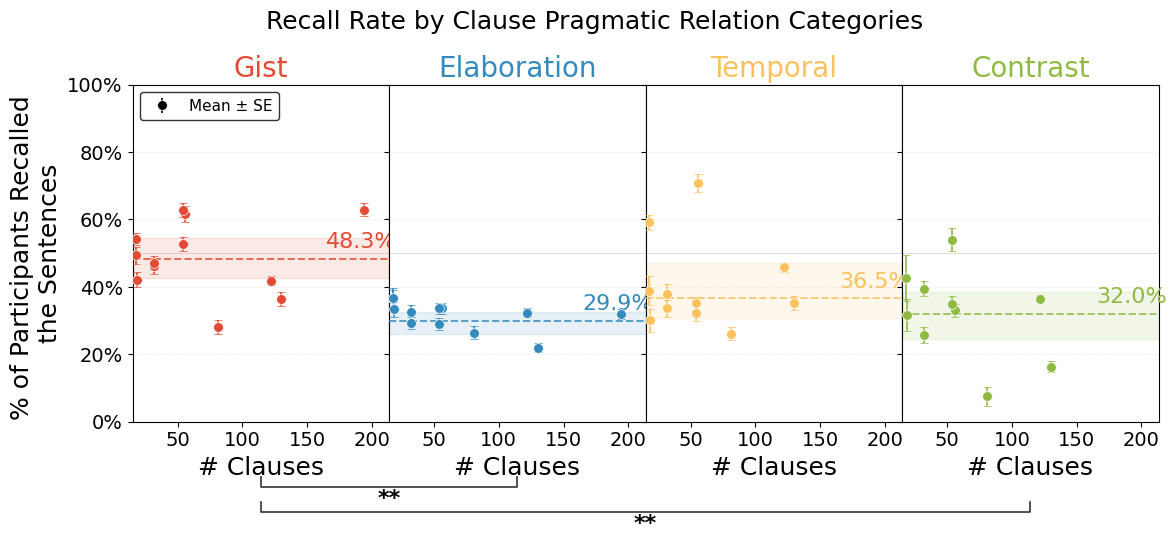

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import pingouin as pg
import pandas as pd

categories = ['main', 'elb', 'temporal', 'contrast']
cat_labels  = ['Gist', 'Elaboration', 'Temporal', 'Contrast']
colors      = ['#E24A33', '#348ABD', '#FBC15E', '#8EBA42']

clauses = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]

index_all = {
    'main':     index_main_all,
    'elb':      index_elb_all,
    'temporal': index_temporal_all,
    'contrast': index_contrast_all,
}

# ── SE per category per story, from participant variability ────────────────
# SE_i = SD(participant rates for story i, ddof=1) / sqrt(n_participants_i)
recall_se_by_category = {cat: [] for cat in recall_by_category_participant}
for cat in recall_by_category_participant:
    for story in range(12):
        p_rates = recall_by_category_participant[cat][story]
        if len(p_rates) > 1:
            se = np.std(p_rates, ddof=1) / np.sqrt(len(p_rates))
        else:
            se = np.nan
        recall_se_by_category[cat].append(se)

cat_vals = {cat: np.array(recall_by_category[cat], dtype=float) for cat in categories}
cat_se   = {cat: np.array(recall_se_by_category[cat], dtype=float) for cat in categories}

# ── repeated measures ANOVA ───────────────────────────────────────────────────
n_stories = len(clauses)
df_long   = pd.DataFrame({
    'story':     list(range(n_stories)) * len(categories),
    'condition': sum([[cat]*n_stories for cat in categories], []),
    'recall':    sum([cat_vals[cat].tolist() for cat in categories], [])
}).dropna()

rm = pg.rm_anova(data=df_long, dv='recall', within='condition',
                 subject='story', detailed=True)
print("Repeated Measures ANOVA:")
print(rm[['Source', 'F', 'p-unc', 'ng2', 'eps']].to_string(index=False))

f_stat  = rm.loc[rm['Source']=='condition', 'F'].values[0]
p_anova = rm.loc[rm['Source']=='condition', 'p-unc'].values[0]

# ── post-hoc paired t-tests with FDR ─────────────────────────────────────────
posthoc = pg.pairwise_tests(data=df_long, dv='recall', within='condition',
                             subject='story', padjust='fdr_bh')
print("\nPost-hoc columns:", posthoc.columns.tolist())
effect_col = 'hedges' if 'hedges' in posthoc.columns else \
             'cohen'  if 'cohen'  in posthoc.columns else \
             posthoc.columns[posthoc.columns.str.contains('cohen|hedges', case=False)][0]
print("\nPost-hoc (FDR corrected):")
print(posthoc[['A','B','T','dof','p-unc','p-corr', effect_col]].to_string(index=False))

sig_pairs = []
for _, row in posthoc.iterrows():
    if row['p-corr'] < 0.05:
        sig_pairs.append((row['A'], row['B'], float(row['p-corr'])))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(12, 5), sharey=True, sharex=True)

for ax, cat, label, col in zip(axes, categories, cat_labels, colors):
    vals    = cat_vals[cat]
    se_vals = cat_se[cat]
    n_cat   = len(vals)
    xs      = clauses[:n_cat]
    weights = np.array([len(index_all[cat][i]) for i in range(n_cat)], dtype=float)
    mask    = ~np.isnan(vals)
    w_avg   = np.average(vals[mask], weights=weights[mask]) if mask.sum() > 0 else np.nan

    # bootstrap CI for weighted mean
    if mask.sum() > 1:
        boot_means = []
        for _ in range(2000):
            idx = np.random.choice(np.where(mask)[0], size=mask.sum(), replace=True)
            boot_means.append(np.average(vals[idx], weights=weights[idx]))
        ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
        ax.axhspan(ci_lo, ci_hi, color=col, alpha=0.12, zorder=2)

    for si in range(n_cat):
        if not np.isnan(vals[si]):
            se_si = se_vals[si] if si < len(se_vals) and not np.isnan(se_vals[si]) else None
            ax.errorbar(xs[si], vals[si], yerr=se_si,
                        fmt='o', color=col, ecolor=col, elinewidth=1.2,
                        capsize=3, markersize=7, zorder=4,
                        markeredgecolor='white', markeredgewidth=0.5)

    if not np.isnan(w_avg):
        ax.axhline(w_avg, color=col, linewidth=1.4, linestyle='--', zorder=3, alpha=0.8)
        ax.text(max(clauses) * 0.85, w_avg + 0.02, f'{w_avg*100:.1f}%', fontsize=16,
                color=col, va='bottom', clip_on=False)

    if ax is axes[0]:
        se_proxy = ax.errorbar([], [], yerr=[], fmt='o', color='black',
                                ecolor='black', elinewidth=1.2, capsize=3,
                                markersize=7, markeredgecolor='white',
                                markeredgewidth=0.5, label='Mean ± SE')
        ax.legend(handles=[se_proxy], fontsize=11, loc='upper left',
                  frameon=True, facecolor='white', edgecolor='black')

    ax.set_title(label, fontsize=20, color=col)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
    ax.axhline(0.5, color='#dddddd', linewidth=0.7, zorder=1)
    ax.grid(axis='y', linestyle=':', linewidth=0.4, alpha=0.5)
    ax.set_xlabel('# Clauses', fontsize=18)
    ax.tick_params(labelsize=14)
    ax.set_xticks([50, 100, 150, 200])



axes[0].set_xlim(min(clauses) * 0.85, max(clauses) * 1.1)
axes[0].set_ylabel('% of Participants Recalled \nthe Sentences', fontsize=18)

p_str = '***' if p_anova < 0.001 else ('**' if p_anova < 0.01 else ('*' if p_anova < 0.05 else 'n.s.'))
fig.suptitle(f'Recall Rate by Clause Pragmatic Relation Categories\n',
             fontsize=18, y=0.97)

plt.tight_layout()
plt.subplots_adjust(wspace=0.0, top=0.82)
fig.canvas.draw()

# ── significance brackets ─────────────────────────────────────────────────────
if sig_pairs:
    ax_pos = [ax.get_position() for ax in axes]
    cat_cx = [(p.x0 + p.x1) / 2 for p in ax_pos]
    bot_y  = min(p.y0 for p in ax_pos)

    sig_pairs_sorted = sorted(sig_pairs,
                               key=lambda x: abs(categories.index(x[0]) - categories.index(x[1])))

    for level, (g1, g2, p_adj) in enumerate(sig_pairs_sorted):
        i1, i2 = categories.index(g1), categories.index(g2)
        if i1 > i2:
            i1, i2 = i2, i1
        x1, x2 = cat_cx[i1], cat_cx[i2]
        y   = bot_y - 0.13 - level * 0.05
        dy  = 0.02
        star = '***' if p_adj < 0.001 else ('**' if p_adj < 0.01 else '*')

        fig.add_artist(plt.Line2D([x1, x1, x2, x2], [y+dy, y, y, y+dy],
                                   transform=fig.transFigure, color='#333333',
                                   linewidth=1.2, clip_on=False))
        fig.text((x1+x2)/2, y - 0.005, star, ha='center', va='top',
                 fontsize=16, transform=fig.transFigure, clip_on=False, fontweight='bold')

plt.savefig('recall_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from scipy import stats as sp_stats
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import pingouin as pg
import pandas as pd

x      = np.array(clauses, dtype=float)
n      = len(x)
n_perm = 10000
n_boot = 10000

# ═══════════════════════════════════════════════════════
# 1. PER-CATEGORY REGRESSION STATS
# ═══════════════════════════════════════════════════════
print("=" * 60)
print("  PER-CATEGORY REGRESSION")
print("=" * 60)

reg_results = {}
for cat, label in zip(categories, cat_labels):
    vals = cat_vals[cat]
    mask = ~np.isnan(vals)
    xc   = x[mask]
    yc   = vals[mask]
    nc   = len(xc)
    dfc  = nc - 2

    sl, ic, r_p, p_param, se = linregress(xc, yc)
    r2       = r_p**2
    cohen_f2 = r2 / (1 - r2 + 1e-10)
    t_obs    = r_p * np.sqrt(dfc) / np.sqrt(1 - r_p**2 + 1e-10)
    t_crit_c = sp_stats.t.ppf(0.975, dfc)
    power    = (1 - sp_stats.t.cdf(t_crit_c, dfc, loc=abs(t_obs))
                  + sp_stats.t.cdf(-t_crit_c, dfc, loc=abs(t_obs)))
    z_r   = np.arctanh(np.clip(r_p, -0.9999, 0.9999))
    se_z  = 1 / np.sqrt(nc - 3)
    ci_r  = [np.tanh(z_r - 1.96*se_z), np.tanh(z_r + 1.96*se_z)]
    X_sm  = sm.add_constant(xc)
    m_sm  = sm.OLS(yc, X_sm).fit()
    ci_slope = m_sm.conf_int(alpha=0.05)[1]

    reg_results[cat] = dict(xc=xc, yc=yc, nc=nc, dfc=dfc,
                             sl=sl, r=r_p, r2=r2, p=p_param,
                             t=t_obs, f2=cohen_f2, power=power,
                             ci_r=ci_r, ci_slope=ci_slope,
                             t_crit_c=t_crit_c)

    print(f"\n  {label.upper()}")
    print(f"    n            = {nc}")
    print(f"    slope        = {sl:.4f}  CI=[{ci_slope[0]:.4f}, {ci_slope[1]:.4f}]")
    print(f"    intercept    = {ic:.4f}")
    print(f"    t({dfc})      = {t_obs:.4f}   p = {p_param:.4e}")
    print(f"    Pearson r    = {r_p:.4f}   CI=[{ci_r[0]:.4f}, {ci_r[1]:.4f}]")
    print(f"    R²           = {r2:.4f}  ({r2*100:.1f}%)")
    print(f"    Cohen's f²   = {cohen_f2:.4f}  ({'small' if cohen_f2<0.15 else 'medium' if cohen_f2<0.35 else 'large'})")
    print(f"    Power        = {power:.4f}")

# ═══════════════════════════════════════════════════════
# 2. REPEATED MEASURES ANOVA
# ═══════════════════════════════════════════════════════
n_stories = len(clauses)
df_long   = pd.DataFrame({
    'story':     list(range(n_stories)) * len(categories),
    'condition': sum([[cat]*n_stories for cat in categories], []),
    'recall':    sum([cat_vals[cat].tolist() for cat in categories], [])
}).dropna()

rm = pg.rm_anova(data=df_long, dv='recall', within='condition',
                 subject='story', detailed=True)

print(f"\n{'='*60}")
print("  REPEATED MEASURES ANOVA")
print(f"{'='*60}")
print(f"  columns: {rm.columns.tolist()}")
print(rm.to_string(index=False))

f_stat  = rm.loc[rm['Source']=='condition', 'F'].values[0]
p_anova = rm.loc[rm['Source']=='condition', 'p-unc'].values[0]
ng2     = rm.loc[rm['Source']=='condition', 'ng2'].values[0]
eps_col = next((c for c in rm.columns if 'eps' in c.lower()), None)
eps     = rm.loc[rm['Source']=='condition', eps_col].values[0] if eps_col else float('nan')

# ── degrees of freedom — robust to old/new pingouin ──
cond_row = rm[rm['Source'] == 'condition']
err_row  = rm[rm['Source'].str.contains('error|within|residual', case=False, na=False)]

df1_col = next((c for c in rm.columns
                if c.lower() in ('ddof1', 'df', 'df1', 'dof1')), None)
df2_col = next((c for c in rm.columns
                if c.lower() in ('ddof2', 'df2', 'dof2', 'df_error', 'dferror')), None)

if df1_col is not None:
    df1 = float(cond_row[df1_col].values[0])
else:
    df1 = float(len(categories) - 1)

df2 = None
if df2_col is not None:
    v = cond_row[df2_col].values
    if len(v) and not np.isnan(float(v[0])):
        df2 = float(v[0])
if df2 is None and df2_col is not None and len(err_row):
    v = err_row[df2_col].values
    if len(v) and not np.isnan(float(v[0])):
        df2 = float(v[0])
if df2 is None:
    n_subj = df_long['story'].nunique()
    df2    = (len(categories) - 1) * (n_subj - 1)

ncp         = f_stat * df1
f_crit      = sp_stats.f.ppf(0.95, df1, df2)
power_anova = 1 - sp_stats.ncf.cdf(f_crit, df1, df2, ncp)

print(f"\n  F({int(df1)}, {int(df2)}) = {f_stat:.4f}   p = {p_anova:.4e}")
print(f"  η²g (effect)  = {ng2:.4f}  ({'small' if ng2<0.06 else 'medium' if ng2<0.14 else 'large'})")
if not np.isnan(eps):
    print(f"  Sphericity ε  = {eps:.4f}")
print(f"  Power         = {power_anova:.4f}")

# ── post-hoc ──
posthoc    = pg.pairwise_tests(data=df_long, dv='recall', within='condition',
                                subject='story', padjust='fdr_bh',
                                effsize='hedges')
effect_col = next((c for c in posthoc.columns
                   if 'hedges' in c.lower() or 'cohen' in c.lower()), None)

# power for each paired t-test using observed t as ncp
powers = []
for _, row in posthoc.iterrows():
    dof    = float(row['dof'])
    t_obs  = abs(float(row['T']))
    t_crit = sp_stats.t.ppf(0.975, dof)
    pwr    = (1 - sp_stats.t.cdf(t_crit, dof, loc=t_obs)
                + sp_stats.t.cdf(-t_crit, dof, loc=t_obs))
    powers.append(pwr)
posthoc['power'] = powers

cols_ph = ['A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'power'] + ([effect_col] if effect_col else [])
print(f"\n  POST-HOC (paired t-test, FDR corrected)")
print(posthoc[cols_ph].to_string(index=False))


# ═══════════════════════════════════════════════════════
# 3. PERMUTATION
# ═══════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  PERMUTATION (n={n_perm})")
print(f"{'='*60}")

for cat, label in zip(categories, cat_labels):
    xc, yc = reg_results[cat]['xc'], reg_results[cat]['yc']
    r_obs  = reg_results[cat]['r']
    r_null = [linregress(np.random.permutation(xc), yc)[2] for _ in range(n_perm)]
    p_perm = np.mean(np.abs(r_null) >= np.abs(r_obs))
    print(f"  {label:<14} r={r_obs:.4f}  p_perm={p_perm:.4f}")

f_null = []
rng_p  = np.random.default_rng(0)
for _ in range(n_perm):
    df_shuf           = df_long.copy()
    df_shuf['recall'] = rng_p.permutation(df_shuf['recall'].values)
    try:
        res = pg.rm_anova(data=df_shuf, dv='recall', within='condition',
                          subject='story', detailed=False)
        f_null.append(float(res['F'].values[0]))
    except Exception:
        continue
p_perm_anova = np.mean(np.array(f_null) >= f_stat)
print(f"\n  RM-ANOVA  F_obs={f_stat:.4f}  p_perm={p_perm_anova:.4f}  "
      f"(n_valid={len(f_null)})")

# ═══════════════════════════════════════════════════════
# 4. BOOTSTRAP — regression per category
# ═══════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  BOOTSTRAP (n={n_boot})")
print(f"{'='*60}")

rng_b = np.random.default_rng(1)
for cat, label in zip(categories, cat_labels):
    xc, yc   = reg_results[cat]['xc'], reg_results[cat]['yc']
    nc       = reg_results[cat]['nc']
    t_crit_c = reg_results[cat]['t_crit_c']

    r_b, sl_b, r2_b, t_b, f2_b = [], [], [], [], []
    for _ in range(n_boot):
        idx = rng_b.choice(nc, nc, replace=True)
        xb, yb = xc[idx], yc[idx]
        if len(np.unique(xb)) < 2:
            continue
        sl_, _, r_, _, _ = linregress(xb, yb)
        r2_ = r_**2
        t_  = r_ * np.sqrt(nc - 2) / np.sqrt(1 - r_**2 + 1e-10)
        r_b.append(r_);  sl_b.append(sl_)
        r2_b.append(r2_); t_b.append(t_)
        f2_b.append(r2_ / (1 - r2_ + 1e-10))

    r_b  = np.array(r_b);  sl_b = np.array(sl_b)
    r2_b = np.array(r2_b); t_b  = np.array(t_b)
    f2_b = np.array(f2_b)

    p_boot   = 2 * min(np.mean(r_b <= 0), np.mean(r_b >= 0))
    pow_boot = np.mean(np.abs(t_b) >= t_crit_c)

    print(f"\n  {label.upper()}")
    print(f"    p            = {p_boot:.4f}")
    print(f"    slope        = {np.mean(sl_b):.4f}  CI=[{np.percentile(sl_b,2.5):.4f}, {np.percentile(sl_b,97.5):.4f}]")
    print(f"    r            = {np.mean(r_b):.4f}  CI=[{np.percentile(r_b,2.5):.4f}, {np.percentile(r_b,97.5):.4f}]")
    print(f"    R²           = {np.mean(r2_b):.4f}  CI=[{np.percentile(r2_b,2.5):.4f}, {np.percentile(r2_b,97.5):.4f}]")
    print(f"    Cohen's f²   = {np.mean(f2_b):.4f}  CI=[{np.percentile(f2_b,2.5):.4f}, {np.percentile(f2_b,97.5):.4f}]")
    print(f"    Power        = {pow_boot:.4f}")

print("=" * 60)
